# ============================================
# ------------------------------  UK ------------------------------------
# ------------------- COLONIZER TO COLLAPSE   ---------------------
# ============================================

## Establishing Connection

In [1]:
import pandas as pd 
from sqlalchemy import create_engine, text

print("Tools loaded.")

   # <-- change this one line

host = "localhost"      
port = 3306           
username = "root"  
my_password = "Newkirat#124"
database_name = "uk_decline_db"   
    
connection_url = f"mysql+pymysql://{username}:{my_password}@{host}:{port}/"
engine = create_engine(connection_url)

print("Connected to MySQL.")


# ============================================================
# STEP 4: Create our project's database (like creating a new Excel file)
# ============================================================
with engine.connect() as connection:
    connection.execute(text(f"CREATE DATABASE IF NOT EXISTS {database_name}"))
    connection.commit()

print(f"Database '{database_name}' is ready.")


# ============================================================
# STEP 5: Now connect specifically INTO that database
# ============================================================
# Same as before, but now we tell it which database to use

connection_url_with_db = f"mysql+pymysql://{username}:{my_password}@{host}:{port}/{database_name}"
engine = create_engine(connection_url_with_db)

print(f"Now connected inside '{database_name}'.")


# ============================================================
# STEP 6: Read the schema.sql file (the instructions for our tables)
# ============================================================
# Make sure schema.sql is saved in the SAME folder as this notebook

with open("schema.sql", "r") as file:
    schema_text = file.read()

print("Schema file loaded.")


# ============================================================
# STEP 7: Run each instruction in the schema file, one at a time
# ============================================================
# The schema file has multiple "CREATE TABLE" commands separated by semicolons (;)
# We split them apart and run them one by one

commands = schema_text.split(";")

with engine.connect() as connection:
    for command in commands:
        command = command.strip()   # remove extra blank spaces
        if command != "":            # skip empty lines
            connection.execute(text(command))
    connection.commit()

print("All tables created successfully!")


# ============================================================
# STEP 8: Double check - ask MySQL to list the tables it made
# ============================================================
with engine.connect() as connection:
    result = connection.execute(text("SHOW TABLES"))
    print("\nTables in your database:")
    for row in result:
        print(" -", row[0])

Tools loaded.
Connected to MySQL.
Database 'uk_decline_db' is ready.
Now connected inside 'uk_decline_db'.
Schema file loaded.
All tables created successfully!

Tables in your database:
 - dim_date
 - dim_event
 - dim_pm
 - fact_annual_indicators
 - fact_cpi_monthly
 - fact_energy_price_cap
 - fact_gdp_quarterly
 - fact_markets_daily
 - fact_wealth_migration
 - fact_wealth_nondom


## Loading and Cleaning

In [2]:
from datetime import date, timedelta

start = date(2008, 1, 1)
end = date(2026, 12, 31)

rows = []
current = start
while current <= end:
    date_key = int(current.strftime("%Y%m%d"))
    year = current.year
    month = current.month
    quarter = (month - 1) // 3 + 1
    month_name = current.strftime("%B")
    day = current.day

    rows.append({
        "date_key": date_key,
        "full_date": current,
        "year": year,
        "quarter": quarter,
        "month": month,
        "month_name": month_name,
        "day": day
    })
    current += timedelta(days=1)

dim_date_df = pd.DataFrame(rows)
print(f"Built {len(dim_date_df)} rows for dim_date.")
print(dim_date_df.head())

dim_date_df.to_sql("dim_date", con=engine, if_exists="replace", index=False)
print("dim_date loaded into MySQL successfully!")

check = pd.read_sql("SELECT * FROM dim_date LIMIT 5", con=engine)
print("\nSample rows from MySQL:")
print(check)

count = pd.read_sql("SELECT COUNT(*) as total_rows FROM dim_date", con=engine)
print("\nTotal rows in dim_date:", count["total_rows"][0])

Built 6940 rows for dim_date.
   date_key   full_date  year  quarter  month month_name  day
0  20080101  2008-01-01  2008        1      1    January    1
1  20080102  2008-01-02  2008        1      1    January    2
2  20080103  2008-01-03  2008        1      1    January    3
3  20080104  2008-01-04  2008        1      1    January    4
4  20080105  2008-01-05  2008        1      1    January    5
dim_date loaded into MySQL successfully!

Sample rows from MySQL:
   date_key   full_date  year  quarter  month month_name  day
0  20080101  2008-01-01  2008        1      1    January    1
1  20080102  2008-01-02  2008        1      1    January    2
2  20080103  2008-01-03  2008        1      1    January    3
3  20080104  2008-01-04  2008        1      1    January    4
4  20080105  2008-01-05  2008        1      1    January    5

Total rows in dim_date: 6940


In [3]:
# This just OPENS your file and shows you what's inside.
# It doesn't save anything to the database yet - we're just looking first.

pm_df = pd.read_excel("uk_prime_ministers_2007_2026.xlsx")

# Show the column names (the headers of each column)
print("Your file's column names are:")
print(pm_df.columns.tolist())

# Show the first few rows so we can see the actual data
pm_df

Your file's column names are:
['UK Prime Ministers Timeline', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']


,UK Prime Ministers Timeline,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,"Historical Overview of Tenures, Parties, and R...",NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,PM Name,Tenure,Party,Exit Reason
3,Tony Blair,"May 2, 2007 - Jun 27, 2007 (Full tenure: 1997–...",Labour,Resigned voluntarily to allow Gordon Brown to ...
4,Gordon Brown,"Jun 27, 2007 - May 11, 2010",Labour,Resigned after losing the general election.
5,David Cameron,"May 11, 2010 - Jul 13, 2016",Conservative,Resigned immediately after losing the Brexit r...
6,Theresa May,"Jul 13, 2016 - Jul 24, 2019",Conservative,Resigned after failing to pass her Brexit deal...
7,Boris Johnson,"Jul 24, 2019 - Sep 6, 2022",Conservative,Forced to resign due to multiple scandals and ...
8,Liz Truss,"Sep 6, 2022 - Oct 25, 2022",Conservative,Resigned after just 44 days following market t...
9,Rishi Sunak,"Oct 25, 2022 - Jul 5, 2024",Conservative,Resigned after the Conservative Party lost the...


In [4]:
import re

pm_df = pd.read_excel("uk_prime_ministers_2007_2026.xlsx", skiprows=3)
pm_df = pm_df.rename(columns={"PM Name": "pm_name", "Tenure": "tenure_text",
                                "Party": "party", "Exit Reason": "exit_reason"})

date_pattern = r"[A-Za-z]+\s+\d{1,2},\s*\d{4}|[A-Za-z]+\s+\d{4}"

# THE FIX: loop through row by row, converting each date individually,
# instead of asking pandas to convert an entire column all at once.
# This avoids a pandas quirk where batch-converting a column can guess
# one date format from the first value and wrongly reject valid dates
# that don't match that same format later in the column.

start_dates = []
end_dates = []

for text in pm_df["tenure_text"]:
    matches = re.findall(date_pattern, str(text))

    if len(matches) >= 1:
        start_dates.append(pd.to_datetime(matches[0]))
    else:
        start_dates.append(pd.NaT)

    if len(matches) >= 2:
        end_dates.append(pd.to_datetime(matches[1]))
    else:
        end_dates.append(pd.NaT)

pm_df["start_date"] = start_dates
pm_df["end_date"] = end_dates

# Fix Starmer's exact resignation date (his row only said "Jun 2026", no day)
pm_df.loc[pm_df["pm_name"] == "Keir Starmer", "end_date"] = pd.Timestamp("2026-06-22")

print("Final result:")
pm_df[["pm_name", "start_date", "end_date", "party", "exit_reason"]]

Final result:


,pm_name,start_date,end_date,party,exit_reason
0,Tony Blair,2007-05-02,2007-06-27,Labour,Resigned voluntarily to allow Gordon Brown to ...
1,Gordon Brown,2007-06-27,2010-05-11,Labour,Resigned after losing the general election.
2,David Cameron,2010-05-11,2016-07-13,Conservative,Resigned immediately after losing the Brexit r...
3,Theresa May,2016-07-13,2019-07-24,Conservative,Resigned after failing to pass her Brexit deal...
4,Boris Johnson,2019-07-24,2022-09-06,Conservative,Forced to resign due to multiple scandals and ...
5,Liz Truss,2022-09-06,2022-10-25,Conservative,Resigned after just 44 days following market t...
6,Rishi Sunak,2022-10-25,2024-07-05,Conservative,Resigned after the Conservative Party lost the...
7,Keir Starmer,2024-07-05,2026-06-22,Labour,Announced his resignation amid internal party ...


In [5]:
# Keep only the columns MySQL needs
pm_final = pm_df[["pm_name", "start_date", "end_date", "party", "exit_reason"]]

# Save into MySQL (replaces whatever was there before)
pm_final.to_sql("dim_pm", con=engine, if_exists="replace", index=False)
print("dim_pm saved successfully!")

# Read it back to confirm
check = pd.read_sql("SELECT * FROM dim_pm", con=engine)
check

dim_pm saved successfully!


,pm_name,start_date,end_date,party,exit_reason
0,Tony Blair,2007-05-02,2007-06-27,Labour,Resigned voluntarily to allow Gordon Brown to ...
1,Gordon Brown,2007-06-27,2010-05-11,Labour,Resigned after losing the general election.
2,David Cameron,2010-05-11,2016-07-13,Conservative,Resigned immediately after losing the Brexit r...
3,Theresa May,2016-07-13,2019-07-24,Conservative,Resigned after failing to pass her Brexit deal...
4,Boris Johnson,2019-07-24,2022-09-06,Conservative,Forced to resign due to multiple scandals and ...
5,Liz Truss,2022-09-06,2022-10-25,Conservative,Resigned after just 44 days following market t...
6,Rishi Sunak,2022-10-25,2024-07-05,Conservative,Resigned after the Conservative Party lost the...
7,Keir Starmer,2024-07-05,2026-06-22,Labour,Announced his resignation amid internal party ...


In [6]:
event_df = pd.read_excel("uk_key_events_2016_2026_corrected.xlsx")
print(event_df.columns.tolist())
event_df

['Date', 'Event', 'Type', 'Description']


,Date,Event,Type,Description
0,2016-06-23,Brexit Referendum,Political / Structural,"The UK votes to leave the EU (52% to 48%), ini..."
1,2017-03-29,Article 50 Triggered,Political,"Formally began the two-year exit countdown, es..."
2,2019-07-24,Boris Johnson becomes PM,Political,Shifted government focus toward a hard Brexit ...
3,2020-01-31,Official Brexit Day,Structural,"The UK officially leaves the European Union, i..."
4,2020-03-23,First COVID-19 Lockdown,Macroeconomic,Triggered a historic quarterly GDP contraction...
5,2022-02-24,Russian Invasion of Ukraine,Global Shock,Sparked a massive energy and commodity supply ...
6,2022-09-23,The 'Mini-Budget',Fiscal Policy,Unfunded tax cuts under Liz Truss triggered se...
7,2022-10-25,Rishi Sunak becomes PM,Political,"Appointed to restore market confidence, stabil..."
8,2024-07-04,UK General Election,Political,Labour wins a landslide victory; Sir Keir Star...
9,2024-10-30,Reeves' Autumn Budget,Fiscal Policy,Chancellor Rachel Reeves introduces tax reform...


In [7]:
event_df = pd.read_excel("uk_key_events_2016_2026_corrected.xlsx")

# Just rename columns to match what MySQL expects
event_df = event_df.rename(columns={
    "Date": "event_date",
    "Event": "event_name",
    "Type": "event_type",
    "Description": "description"
})

# Make sure event_date is a proper date (not just text)
event_df["event_date"] = pd.to_datetime(event_df["event_date"])

print("Preview before saving:")
print(event_df.head())

# Save into MySQL
event_df.to_sql("dim_event", con=engine, if_exists="replace", index=False)
print("\ndim_event saved successfully!")

# Confirm by reading back
check = pd.read_sql("SELECT * FROM dim_event", con=engine)
check

Preview before saving:
  event_date                event_name              event_type  \
0 2016-06-23         Brexit Referendum  Political / Structural   
1 2017-03-29      Article 50 Triggered               Political   
2 2019-07-24  Boris Johnson becomes PM               Political   
3 2020-01-31       Official Brexit Day              Structural   
4 2020-03-23   First COVID-19 Lockdown           Macroeconomic   

                                         description  
0  The UK votes to leave the EU (52% to 48%), ini...  
1  Formally began the two-year exit countdown, es...  
2  Shifted government focus toward a hard Brexit ...  
3  The UK officially leaves the European Union, i...  
4  Triggered a historic quarterly GDP contraction...  

dim_event saved successfully!


,event_date,event_name,event_type,description
0,2016-06-23,Brexit Referendum,Political / Structural,"The UK votes to leave the EU (52% to 48%), ini..."
1,2017-03-29,Article 50 Triggered,Political,"Formally began the two-year exit countdown, es..."
2,2019-07-24,Boris Johnson becomes PM,Political,Shifted government focus toward a hard Brexit ...
3,2020-01-31,Official Brexit Day,Structural,"The UK officially leaves the European Union, i..."
4,2020-03-23,First COVID-19 Lockdown,Macroeconomic,Triggered a historic quarterly GDP contraction...
5,2022-02-24,Russian Invasion of Ukraine,Global Shock,Sparked a massive energy and commodity supply ...
6,2022-09-23,The 'Mini-Budget',Fiscal Policy,Unfunded tax cuts under Liz Truss triggered se...
7,2022-10-25,Rishi Sunak becomes PM,Political,"Appointed to restore market confidence, stabil..."
8,2024-07-04,UK General Election,Political,Labour wins a landslide victory; Sir Keir Star...
9,2024-10-30,Reeves' Autumn Budget,Fiscal Policy,Chancellor Rachel Reeves introduces tax reform...


In [8]:
cpi_df = pd.read_excel("CPI_INFLATION.xlsx")
print(cpi_df.columns.tolist())
cpi_df.head()


['Period', 'CPI_Annual_Rate_Pct']


,Period,CPI_Annual_Rate_Pct
0,2008 JAN,2.2
1,2008 FEB,2.5
2,2008 MAR,2.5
3,2008 APR,3.0
4,2008 MAY,3.3


In [9]:
cpi_df = pd.read_excel("CPI_INFLATION.xlsx")

# Convert "2008 JAN" style text into a real date (1st of that month)
# Using the same safe row-by-row approach that worked reliably for dim_pm

date_keys = []
for period_text in cpi_df["Period"]:
    parsed_date = pd.to_datetime(period_text, format="%Y %b")
    date_key = int(parsed_date.strftime("%Y%m%d"))
    date_keys.append(date_key)

cpi_df["date_key"] = date_keys
cpi_df = cpi_df.rename(columns={"CPI_Annual_Rate_Pct": "cpi_annual_rate_pct"})

# Keep only what MySQL needs
cpi_final = cpi_df[["date_key", "cpi_annual_rate_pct"]]

print("Preview before saving:")
print(cpi_final.head())
print("...")
print(cpi_final.tail())

# Save to MySQL
cpi_final.to_sql("fact_cpi_monthly", con=engine, if_exists="replace", index=False)
print("\nfact_cpi_monthly saved successfully!")

# Confirm
count = pd.read_sql("SELECT COUNT(*) as total_rows FROM fact_cpi_monthly", con=engine)
print("Total rows:", count["total_rows"][0])

Preview before saving:
   date_key  cpi_annual_rate_pct
0  20080101                  2.2
1  20080201                  2.5
2  20080301                  2.5
3  20080401                  3.0
4  20080501                  3.3
...
     date_key  cpi_annual_rate_pct
216  20260101                  3.0
217  20260201                  3.0
218  20260301                  3.3
219  20260401                  2.8
220  20260501                  2.8

fact_cpi_monthly saved successfully!
Total rows: 221


In [10]:
gdp_df = pd.read_excel("UK GDP QUATERLY.xlsx")
print(gdp_df.columns.tolist())
gdp_df.head(15)

['Title', 'Gross Domestic Product: Quarter on Quarter growth: CVM SA %', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6']


,Title,Gross Domestic Product: Quarter on Quarter growth: CVM SA %,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,CDID,IHYQ,NaN,NaN,NaN,NaN,NaN
1,Source dataset ID,PN2,NaN,NaN,NaN,NaN,NaN
2,PreUnit,NaN,NaN,NaN,NaN,NaN,NaN
3,Unit,%,NaN,NaN,NaN,NaN,NaN
4,Release date,14-05-2026,NaN,NaN,NaN,2000 Q1,1.3
5,Next release,2026-06-30 00:00:00,NaN,NaN,NaN,2000 Q2,0.7
6,Important notes,NaN,NaN,NaN,NaN,2000 Q3,0.6
7,NaN,NaN,NaN,NaN,NaN,2000 Q4,0.6
8,NaN,NaN,NaN,NaN,NaN,2001 Q1,0.8
9,NaN,NaN,NaN,NaN,NaN,2001 Q2,0.4


In [11]:
gdp_raw = pd.read_excel("UK GDP QUATERLY.xlsx")

# The real data lives in "Unnamed: 5" (period like "2000 Q1") and
# "Unnamed: 6" (the actual growth % value). Everything else on the
# left side is just metadata (CDID, source info) that we don't need.

gdp_clean = pd.DataFrame({
    "period_text": gdp_raw["Unnamed: 5"],
    "gdp_qoq_growth_pct": gdp_raw["Unnamed: 6"]
})

# Drop rows where there's no actual data (the metadata rows at the top)
gdp_clean = gdp_clean.dropna()

print("Preview after extracting the real data:")
print(gdp_clean.head())
print("...")
print(gdp_clean.tail())

# Convert "2000 Q1" style text into a real date (1st day of that quarter)
quarter_start_month = {1: 1, 2: 4, 3: 7, 4: 10}

date_keys = []
for text in gdp_clean["period_text"]:
    year_part, quarter_part = text.split(" Q")
    year = int(year_part)
    quarter = int(quarter_part)
    month = quarter_start_month[quarter]
    date_key = int(f"{year}{month:02d}01")
    date_keys.append(date_key)

gdp_clean["date_key"] = date_keys

gdp_final = gdp_clean[["date_key", "gdp_qoq_growth_pct"]]

print("\nFinal preview:")
print(gdp_final.head())

# Save to MySQL
gdp_final.to_sql("fact_gdp_quarterly", con=engine, if_exists="replace", index=False)
print("\nfact_gdp_quarterly saved successfully!")

count = pd.read_sql("SELECT COUNT(*) as total_rows FROM fact_gdp_quarterly", con=engine)
print("Total rows:", count["total_rows"][0])

Preview after extracting the real data:
  period_text  gdp_qoq_growth_pct
4     2000 Q1                 1.3
5     2000 Q2                 0.7
6     2000 Q3                 0.6
7     2000 Q4                 0.6
8     2001 Q1                 0.8
...
    period_text  gdp_qoq_growth_pct
104     2025 Q1                 0.6
105     2025 Q2                 0.1
106     2025 Q3                 0.2
107     2025 Q4                 0.2
108     2026 Q1                 0.6

Final preview:
   date_key  gdp_qoq_growth_pct
4  20000101                 1.3
5  20000401                 0.7
6  20000701                 0.6
7  20001001                 0.6
8  20010101                 0.8

fact_gdp_quarterly saved successfully!
Total rows: 105


In [12]:
energy_df = pd.read_csv("ENERGY_PRICE_CAP.csv")
print(energy_df.columns.tolist())
energy_df

['Source: Ofgem price cap (GBP/year, typical dual-fuel Direct Debit household). Q4 2022-Q1 2023 capped by govt Energy Price Guarantee, not Ofgem cap.']


,"Source: Ofgem price cap (GBP/year, typical dual-fuel Direct Debit household). Q4 2022-Q1 2023 capped by govt Energy Price Guarantee, not Ofgem cap."
Period,Annual_Bill_GBP
2019 Q1,1137
2021 Q2,1138
2021 Q4,1277
2022 Q2,1971
2022 Q4 (EPG),2500
2023 Q1 (EPG),2500
2023 Q2,2074
2023 Q3,1923
2023 Q4,1834


In [13]:
energy_df = pd.read_csv("ENERGY_PRICE_CAP.csv", skiprows=1)

print("Preview:")
print(energy_df)

# Remove " (EPG)" tags from period text (e.g. "2022 Q4 (EPG)" -> "2022 Q4")
# so we can parse the quarter cleanly. We keep the EPG info in mind but
# don't need it as a separate column for now.
energy_df["Period"] = energy_df["Period"].str.replace(r"\s*\(EPG\)", "", regex=True)

# Convert "2019 Q1" style text into a real date (1st day of that quarter)
quarter_start_month = {1: 1, 2: 4, 3: 7, 4: 10}

date_keys = []
for text in energy_df["Period"]:
    year_part, quarter_part = text.split(" Q")
    year = int(year_part)
    quarter = int(quarter_part)
    month = quarter_start_month[quarter]
    date_key = int(f"{year}{month:02d}01")
    date_keys.append(date_key)

energy_df["date_key"] = date_keys
energy_df = energy_df.rename(columns={"Period": "period_label", "Annual_Bill_GBP": "annual_bill_gbp"})

energy_final = energy_df[["date_key", "period_label", "annual_bill_gbp"]]

print("\nFinal preview:")
print(energy_final)

energy_final.to_sql("fact_energy_price_cap", con=engine, if_exists="replace", index=False)
print("\nfact_energy_price_cap saved successfully!")

count = pd.read_sql("SELECT COUNT(*) as total_rows FROM fact_energy_price_cap", con=engine)
print("Total rows:", count["total_rows"][0])

Preview:
           Period  Annual_Bill_GBP
0         2019 Q1             1137
1         2021 Q2             1138
2         2021 Q4             1277
3         2022 Q2             1971
4   2022 Q4 (EPG)             2500
5   2023 Q1 (EPG)             2500
6         2023 Q2             2074
7         2023 Q3             1923
8         2023 Q4             1834
9         2024 Q1             1928
10        2024 Q2             1690
11        2024 Q3             1568
12        2024 Q4             1717
13        2025 Q2             1849
14        2025 Q3             1720
15        2025 Q4             1755
16        2026 Q1             1758
17        2026 Q2             1641
18        2026 Q3             1862

Final preview:
    date_key period_label  annual_bill_gbp
0   20190101      2019 Q1             1137
1   20210401      2021 Q2             1138
2   20211001      2021 Q4             1277
3   20220401      2022 Q2             1971
4   20221001      2022 Q4             2500
5   20230101     

In [14]:
print("=== DEBT_TO_GDP_RATIO_corrected.csv ===")
print(pd.read_csv("DEBT_TO_GDP_RATIO_corrected.csv", skiprows=2).head())

print("\n=== UK_UNEMPLOYMENT_RATE.xlsx ===")
print(pd.read_excel("UK_UNEMPLOYMENT_RATE.xlsx").head())

print("\n=== UK_REAL_WAGE_GROWTH_labeled.xlsx ===")
print(pd.read_excel("UK_REAL_WAGE_GROWTH_labeled.xlsx", skiprows=1).head())

print("\n=== UK_10Y_GILT_YIELD.csv ===")
print(pd.read_csv("UK_10Y_GILT_YIELD.csv", skiprows=1).head())

print("\n=== TAX_TO_GDP_final.csv ===")
print(pd.read_csv("TAX_TO_GDP_final.csv", skiprows=1).head())

print("\n=== UK_EU_TRADE_GOODS_final.csv ===")
print(pd.read_csv("UK_EU_TRADE_GOODS_final.csv", skiprows=1).head())

=== DEBT_TO_GDP_RATIO_corrected.csv ===
   YEAR   RATIO  Unnamed: 2  Unnamed: 3
0  2025  94.70%         NaN         NaN
1  2024  94.70%         NaN         NaN
2  2023  95.60%         NaN         NaN
3  2022  93.10%         NaN         NaN
4  2021  96.20%         NaN         NaN

=== UK_UNEMPLOYMENT_RATE.xlsx ===
   Year  Unemployment_Rate_Pct
0  2008                    5.7
1  2009                    7.6
2  2010                    7.9
3  2011                    8.1
4  2012                    7.9

=== UK_REAL_WAGE_GROWTH_labeled.xlsx ===
   Year  Real_AWE_GBP_per_week
0  2008                    505
1  2009                    495
2  2010                    494
3  2011                    487
4  2012                    481

=== UK_10Y_GILT_YIELD.csv ===
   Year  Yield_Pct
0  2008     4.5948
1  2009     3.6481
2  2010     3.6180
3  2011     3.1241
4  2012     1.9162

=== TAX_TO_GDP_final.csv ===
   Year  Total_Revenue_GBPm  GDP_CurrentPrices_GBPm  Revenue_to_GDP_Pct
0  1990              227

In [15]:
# ---- Load and clean each file individually first ----

# 1. Debt to GDP
debt_df = pd.read_csv("DEBT_TO_GDP_RATIO_corrected.csv", skiprows=2)
debt_df = debt_df[["YEAR", "RATIO"]].rename(columns={"YEAR": "year"})
# RATIO is text like "94.70%" - remove the % sign and convert to a number
debt_df["debt_to_gdp_pct"] = debt_df["RATIO"].str.replace("%", "").astype(float)
debt_df = debt_df[["year", "debt_to_gdp_pct"]]

# 2. Unemployment
unemp_df = pd.read_excel("UK_UNEMPLOYMENT_RATE.xlsx")
unemp_df = unemp_df.rename(columns={"Year": "year", "Unemployment_Rate_Pct": "unemployment_rate_pct"})

# 3. Real wages
wage_df = pd.read_excel("UK_REAL_WAGE_GROWTH_labeled.xlsx", skiprows=1)
wage_df = wage_df.rename(columns={"Year": "year", "Real_AWE_GBP_per_week": "real_awe_gbp_per_week"})

# 4. Gilt yield
gilt_df = pd.read_csv("UK_10Y_GILT_YIELD.csv", skiprows=1)
gilt_df = gilt_df.rename(columns={"Year": "year", "Yield_Pct": "gilt_10y_yield_pct"})

# 5. Tax to GDP (also gives us total revenue and GDP)
tax_df = pd.read_csv("TAX_TO_GDP_final.csv", skiprows=1)
tax_df = tax_df.rename(columns={
    "Year": "year",
    "Total_Revenue_GBPm": "total_revenue_gbpm",
    "GDP_CurrentPrices_GBPm": "gdp_current_price_gbpm",
    "Revenue_to_GDP_Pct": "tax_to_gdp_pct"
})

# 6. EU trade
trade_df = pd.read_csv("UK_EU_TRADE_GOODS_final.csv", skiprows=1)
trade_df = trade_df.rename(columns={
    "Year": "year",
    "Exports_to_EU_GBPm": "eu_exports_gbpm",
    "Imports_from_EU_GBPm": "eu_imports_gbpm",
    "Balance_GBPm": "eu_trade_balance_gbpm"
})

# ---- Merge them all together, one at a time, matching on "year" ----
# how="outer" means: keep every year that appears in ANY file, even if
# some files don't have data for that particular year (those cells just
# become blank/NaN, which is fine and expected)

annual = debt_df.merge(unemp_df, on="year", how="outer")
annual = annual.merge(wage_df, on="year", how="outer")
annual = annual.merge(gilt_df, on="year", how="outer")
annual = annual.merge(tax_df, on="year", how="outer")
annual = annual.merge(trade_df, on="year", how="outer")

annual = annual.sort_values("year").reset_index(drop=True)

print("Merged result:")
print(annual)

# ---- Save to MySQL ----
annual.to_sql("fact_annual_indicators", con=engine, if_exists="replace", index=False)
print("\nfact_annual_indicators saved successfully!")

count = pd.read_sql("SELECT COUNT(*) as total_rows FROM fact_annual_indicators", con=engine)
print("Total rows:", count["total_rows"][0])

Merged result:
    year  debt_to_gdp_pct  unemployment_rate_pct  real_awe_gbp_per_week  \
0   1990              NaN                    NaN                    NaN   
1   1991              NaN                    NaN                    NaN   
2   1992              NaN                    NaN                    NaN   
3   1993              NaN                    NaN                    NaN   
4   1994              NaN                    NaN                    NaN   
5   1995              NaN                    NaN                    NaN   
6   1996              NaN                    NaN                    NaN   
7   1997              NaN                    NaN                    NaN   
8   1998              NaN                    NaN                    NaN   
9   1999              NaN                    NaN                    NaN   
10  2000              NaN                    NaN                    NaN   
11  2001              NaN                    NaN                    NaN   
12  2002  

In [16]:
null_counts = annual.isnull().sum()
print(null_counts)

year                       0
debt_to_gdp_pct           18
unemployment_rate_pct     18
real_awe_gbp_per_week     18
gilt_10y_yield_pct        18
total_revenue_gbpm         0
gdp_current_price_gbpm     0
tax_to_gdp_pct             0
eu_exports_gbpm           18
eu_imports_gbpm           18
eu_trade_balance_gbpm     18
dtype: int64


In [17]:
print("=== NON_DOM_COUNT.csv ===")
print(pd.read_csv("NON_DOM_COUNT.csv", skiprows=1))

print("\n=== HNWI_WEALTH_MIGRATION.csv ===")
print(pd.read_csv("HNWI_WEALTH_MIGRATION.csv", skiprows=2))

=== NON_DOM_COUNT.csv ===
    Tax_Year  Non_Dom_Only_Count  Combined_NonDom_and_DeemedDom_Count
0    2015/16            119400.0                                  NaN
1    2019/20             79500.0                                  NaN
2    2020/21             68300.0                              78400.0
3    2022/23                 NaN                              83800.0
4  2023 (YE)             74000.0                              83900.0
5  2024 (YE)             73700.0                              83000.0

=== HNWI_WEALTH_MIGRATION.csv ===
   Year  Net_HNWI_Migration
0  2016               -1500
1  2023               -4200
2  2024              -10800
3  2025              -16500


In [18]:
# ---- Non-dom counts ----
nondom_df = pd.read_csv("NON_DOM_COUNT.csv", skiprows=1)
nondom_df = nondom_df.rename(columns={
    "Tax_Year": "tax_year",
    "Non_Dom_Only_Count": "non_dom_only_count",
    "Combined_NonDom_and_DeemedDom_Count": "combined_count"
})

print("Non-dom preview:")
print(nondom_df)

nondom_df.to_sql("fact_wealth_nondom", con=engine, if_exists="replace", index=False)
print("fact_wealth_nondom saved!\n")


# ---- HNWI wealth migration ----
migration_df = pd.read_csv("HNWI_WEALTH_MIGRATION.csv", skiprows=2)
migration_df = migration_df.rename(columns={
    "Year": "year",
    "Net_HNWI_Migration": "net_hnwi_migration"
})

print("Migration preview:")
print(migration_df)

migration_df.to_sql("fact_wealth_migration", con=engine, if_exists="replace", index=False)
print("fact_wealth_migration saved!")

# ---- Confirm both ----
print("\n--- Verification ---")
print(pd.read_sql("SELECT * FROM fact_wealth_nondom", con=engine))
print(pd.read_sql("SELECT * FROM fact_wealth_migration", con=engine))

Non-dom preview:
    tax_year  non_dom_only_count  combined_count
0    2015/16            119400.0             NaN
1    2019/20             79500.0             NaN
2    2020/21             68300.0         78400.0
3    2022/23                 NaN         83800.0
4  2023 (YE)             74000.0         83900.0
5  2024 (YE)             73700.0         83000.0
fact_wealth_nondom saved!

Migration preview:
   year  net_hnwi_migration
0  2016               -1500
1  2023               -4200
2  2024              -10800
3  2025              -16500
fact_wealth_migration saved!

--- Verification ---
    tax_year  non_dom_only_count  combined_count
0    2015/16            119400.0             NaN
1    2019/20             79500.0             NaN
2    2020/21             68300.0         78400.0
3    2022/23                 NaN         83800.0
4  2023 (YE)             74000.0         83900.0
5  2024 (YE)             73700.0         83000.0
   year  net_hnwi_migration
0  2016               -1500
1  2

In [19]:
print("=== FTSE100.csv ===")
print(pd.read_csv("FTSE100.csv").head())

print("\n=== SP500.csv ===")
print(pd.read_csv("SP500.csv").head())

print("\n=== GBPUSD.csv ===")
print(pd.read_csv("GBPUSD.csv").head())

=== FTSE100.csv ===
         Date    Open    High     Low   Close
0  2008-01-02  6456.9  6512.3  6402.6  6416.7
1  2008-01-03  6416.7  6487.8  6394.6  6479.4
2  2008-01-04  6479.4  6534.7  6333.2  6348.5
3  2008-01-07  6348.5  6376.5  6275.2  6335.7
4  2008-01-08  6335.7  6399.6  6335.7  6356.5

=== SP500.csv ===
         Date     Open     High      Low    Close
0  2008-01-02  1467.97  1471.77  1442.07  1447.16
1  2008-01-03  1447.55  1456.80  1443.73  1447.16
2  2008-01-04  1444.01  1444.01  1411.19  1411.63
3  2008-01-07  1414.07  1423.87  1403.45  1416.18
4  2008-01-08  1415.71  1430.28  1388.30  1390.19

=== GBPUSD.csv ===
         Date  GBPUSD_Close
0  2008-01-01        1.9868
1  2008-01-02        1.9815
2  2008-01-03        1.9737
3  2008-01-04        1.9739
4  2008-01-07        1.9667


In [20]:
ftse_df = pd.read_csv("FTSE100.csv")
sp500_df = pd.read_csv("SP500.csv")
gbpusd_df = pd.read_csv("GBPUSD.csv")

# Rename columns so each dataset's columns are clearly labeled before merging
# (otherwise all three would have identical "Open", "High", "Low", "Close" names
# and merging would get confused about which is which)

ftse_df = ftse_df.rename(columns={
    "Open": "ftse_open", "High": "ftse_high", "Low": "ftse_low", "Close": "ftse_close"
})
sp500_df = sp500_df.rename(columns={
    "Open": "sp500_open", "High": "sp500_high", "Low": "sp500_low", "Close": "sp500_close"
})
gbpusd_df = gbpusd_df.rename(columns={"GBPUSD_Close": "gbpusd_close"})

# Merge all three together, matching rows by Date
# how="outer" keeps every date that appears in ANY of the three files
# (GBP/USD trades on some days the stock markets are closed, like certain holidays)

markets = ftse_df.merge(sp500_df, on="Date", how="outer")
markets = markets.merge(gbpusd_df, on="Date", how="outer")

markets = markets.sort_values("Date").reset_index(drop=True)

print("Merged preview:")
print(markets.head())
print("...")
print(markets.tail())
print("\nTotal rows after merging:", len(markets))

# Convert Date (text like "2008-01-02") into date_key (20080102)
markets["Date"] = pd.to_datetime(markets["Date"])
markets["date_key"] = markets["Date"].dt.strftime("%Y%m%d").astype(int)

# Keep only the columns MySQL needs, in the right order
markets_final = markets[[
    "date_key", "ftse_open", "ftse_high", "ftse_low", "ftse_close",
    "sp500_open", "sp500_high", "sp500_low", "sp500_close", "gbpusd_close"
]]

# Save to MySQL
markets_final.to_sql("fact_markets_daily", con=engine, if_exists="replace", index=False)
print("\nfact_markets_daily saved successfully!")

count = pd.read_sql("SELECT COUNT(*) as total_rows FROM fact_markets_daily", con=engine)
print("Total rows in MySQL:", count["total_rows"][0])

Merged preview:
         Date  ftse_open  ftse_high  ftse_low  ftse_close  sp500_open  \
0  2008-01-01        NaN        NaN       NaN         NaN         NaN   
1  2008-01-02     6456.9     6512.3    6402.6      6416.7     1467.97   
2  2008-01-03     6416.7     6487.8    6394.6      6479.4     1447.55   
3  2008-01-04     6479.4     6534.7    6333.2      6348.5     1444.01   
4  2008-01-07     6348.5     6376.5    6275.2      6335.7     1414.07   

   sp500_high  sp500_low  sp500_close  gbpusd_close  
0         NaN        NaN          NaN        1.9868  
1     1471.77    1442.07      1447.16        1.9815  
2     1456.80    1443.73      1447.16        1.9737  
3     1444.01    1411.19      1411.63        1.9739  
4     1423.87    1403.45      1416.18        1.9667  
...
            Date  ftse_open  ftse_high  ftse_low  ftse_close  sp500_open  \
6496  2026-06-29   10507.83   10521.03  10471.98    10484.22     7391.88   
6497  2026-06-30   10484.31   10613.18  10483.86    10497.12     

## Cleaning 

In [21]:
# Tony Blair's actual full tenure was May 2, 1997 to June 27, 2007.
# Our source file only captured his last 2 months for some reason - let's correct it.
from sqlalchemy import text
with engine.connect() as conn:
    conn.execute(text("""
        UPDATE dim_pm
        SET start_date = '1997-05-02'
        WHERE pm_name = 'Tony Blair'
    """))
    conn.commit()

print("Blair's start date corrected.")

# Verify
check = pd.read_sql("SELECT * FROM dim_pm ORDER BY start_date", con=engine)
check

Blair's start date corrected.


,pm_name,start_date,end_date,party,exit_reason
0,Tony Blair,1997-05-02,2007-06-27,Labour,Resigned voluntarily to allow Gordon Brown to ...
1,Gordon Brown,2007-06-27,2010-05-11,Labour,Resigned after losing the general election.
2,David Cameron,2010-05-11,2016-07-13,Conservative,Resigned immediately after losing the Brexit r...
3,Theresa May,2016-07-13,2019-07-24,Conservative,Resigned after failing to pass her Brexit deal...
4,Boris Johnson,2019-07-24,2022-09-06,Conservative,Forced to resign due to multiple scandals and ...
5,Liz Truss,2022-09-06,2022-10-25,Conservative,Resigned after just 44 days following market t...
6,Rishi Sunak,2022-10-25,2024-07-05,Conservative,Resigned after the Conservative Party lost the...
7,Keir Starmer,2024-07-05,2026-06-22,Labour,Announced his resignation amid internal party ...


# SQL ANALYSIS 
## (KEY FINDINGS)

### QUESTIONS TO BE ANSWERED
#### PM Comparison
##### 1 Average CPI inflation during each PM's tenure
##### 2 Average GDP growth (QoQ) during each PM's tenure
##### 3 Average unemployment rate during each PM's tenure
##### 4 Average 10Y gilt yield during each PM's tenure
##### 5 Debt-to-GDP at the start vs. end of each PM's tenure (net change)
##### 6 "Misery Index" per PM — average CPI + average unemployment combined, ranked worst to best

#### Trend / change-over-time
##### 7. Year-over-year % change in debt-to-GDP (using SQL LAG() window function)
##### 8. Year-over-year % change in real wages
##### 9. Year-over-year % change in tax-to-GDP
##### 10. Rolling 3-month average CPI vs. energy price cap — do they move together, and does one lead the other?
#### Event-focused
##### 11. Gilt yield, GBP/USD, and FTSE in the 30 days before vs. 30 days after the Truss mini-budget (Sept 23, 2022)
##### 12. Same before/after comparison for the Brexit referendum (Jun 23, 2016)
##### 13. Same before/after comparison for the Ukraine invasion (Feb 24, 2022)
#### Wealth/fiscal
##### 14. Non-dom count trend vs. tax-to-GDP trend — did the tax burden rise as non-doms left?
##### 15. EU trade balance trend before vs. after Brexit (2016 as the dividing line)

## FINDINGS

### 1 Average CPI inflation during each PM's tenure

In [22]:
query1 = """
SELECT
    p.pm_name,
    p.party,
    p.start_date,
    p.end_date,
    ROUND(AVG(c.cpi_annual_rate_pct), 2) AS avg_cpi_during_tenure,
    COUNT(c.date_key) AS months_counted
FROM dim_pm p
JOIN fact_cpi_monthly c
    ON c.date_key >= CAST(DATE_FORMAT(p.start_date, '%%Y%%m%%d') AS UNSIGNED)
    AND c.date_key <= CAST(DATE_FORMAT(COALESCE(p.end_date, CURDATE()), '%%Y%%m%%d') AS UNSIGNED)
GROUP BY p.pm_name, p.party, p.start_date, p.end_date
ORDER BY p.start_date;
"""

result1 = pd.read_sql(query1, con=engine)
print("Average CPI inflation per PM:")
result1

Average CPI inflation per PM:


,pm_name,party,start_date,end_date,avg_cpi_during_tenure,months_counted
0,Gordon Brown,Labour,2007-06-27,2010-05-11,2.98,29
1,David Cameron,Conservative,2010-05-11,2016-07-13,2.19,74
2,Theresa May,Conservative,2016-07-13,2019-07-24,2.25,36
3,Boris Johnson,Conservative,2019-07-24,2022-09-06,3.29,38
4,Liz Truss,Conservative,2022-09-06,2022-10-25,11.10,1
5,Rishi Sunak,Conservative,2022-10-25,2024-07-05,6.14,21
6,Keir Starmer,Labour,2024-07-05,2026-06-22,3.03,22


### 2 Average GDP growth (QoQ) during each PM's tenure

In [23]:
query2 = """
SELECT
    p.pm_name,
    p.party,
    p.start_date,
    p.end_date,
    ROUND(AVG(g.gdp_qoq_growth_pct), 2) AS avg_gdp_growth_during_tenure,
    COUNT(g.date_key) AS quarters_counted
FROM dim_pm p
JOIN fact_gdp_quarterly g
    ON g.date_key >= CAST(DATE_FORMAT(p.start_date, '%%Y%%m%%d') AS UNSIGNED)
    AND g.date_key <= CAST(DATE_FORMAT(COALESCE(p.end_date, CURDATE()), '%%Y%%m%%d') AS UNSIGNED)
GROUP BY p.pm_name, p.party, p.start_date, p.end_date
ORDER BY p.start_date;
"""

result2 = pd.read_sql(query2, con=engine)
print("Average GDP growth per PM:")
result2

Average GDP growth per PM:


,pm_name,party,start_date,end_date,avg_gdp_growth_during_tenure,quarters_counted
0,Tony Blair,Labour,1997-05-02,2007-06-27,0.64,30
1,Gordon Brown,Labour,2007-06-27,2010-05-11,-0.18,12
2,David Cameron,Conservative,2010-05-11,2016-07-13,0.48,25
3,Theresa May,Conservative,2016-07-13,2019-07-24,0.50,12
4,Boris Johnson,Conservative,2019-07-24,2022-09-06,0.54,12
5,Liz Truss,Conservative,2022-09-06,2022-10-25,0.30,1
6,Rishi Sunak,Conservative,2022-10-25,2024-07-05,0.16,7
7,Keir Starmer,Labour,2024-07-05,2026-06-22,0.35,6


### 3 Average unemployment rate during each PM's tenure

In [24]:
# Note: unemployment data is ANNUAL (in fact_annual_indicators), not monthly/daily,
# so this join works a bit differently - we match on YEAR overlap instead of exact date_key.
# We consider a year "part of" a PM's tenure if any part of that year falls within
# their start_date to end_date range.

query3 = """
SELECT
    p.pm_name,
    p.party,
    p.start_date,
    p.end_date,
    ROUND(AVG(a.unemployment_rate_pct), 2) AS avg_unemployment_during_tenure,
    COUNT(a.year) AS years_counted
FROM dim_pm p
JOIN fact_annual_indicators a
    ON a.year >= YEAR(p.start_date)
    AND a.year <= YEAR(COALESCE(p.end_date, CURDATE()))
WHERE a.unemployment_rate_pct IS NOT NULL
GROUP BY p.pm_name, p.party, p.start_date, p.end_date
ORDER BY p.start_date;
"""

result3 = pd.read_sql(query3, con=engine)
print("Average unemployment rate per PM:")
result3

Average unemployment rate per PM:


,pm_name,party,start_date,end_date,avg_unemployment_during_tenure,years_counted
0,Gordon Brown,Labour,2007-06-27,2010-05-11,7.07,3
1,David Cameron,Conservative,2010-05-11,2016-07-13,6.86,7
2,Theresa May,Conservative,2016-07-13,2019-07-24,4.30,4
3,Boris Johnson,Conservative,2019-07-24,2022-09-06,4.20,4
4,Liz Truss,Conservative,2022-09-06,2022-10-25,3.80,1
5,Rishi Sunak,Conservative,2022-10-25,2024-07-05,4.07,3
6,Keir Starmer,Labour,2024-07-05,2026-06-22,4.55,2


### 4 Average 10Y gilt yield during each PM's tenure

In [25]:
query4 = """
SELECT
    p.pm_name,
    p.party,
    p.start_date,
    p.end_date,
    ROUND(AVG(a.gilt_10y_yield_pct), 2) AS avg_gilt_yield_during_tenure,
    COUNT(a.year) AS years_counted
FROM dim_pm p
JOIN fact_annual_indicators a
    ON a.year >= YEAR(p.start_date)
    AND a.year <= YEAR(COALESCE(p.end_date, CURDATE()))
WHERE a.gilt_10y_yield_pct IS NOT NULL
GROUP BY p.pm_name, p.party, p.start_date, p.end_date
ORDER BY p.start_date;
"""
 
result4 = pd.read_sql(query4, con=engine)
print("Average gilt yield per PM:")
print(result4)

Average gilt yield per PM:
         pm_name         party start_date   end_date  \
0   Gordon Brown        Labour 2007-06-27 2010-05-11   
1  David Cameron  Conservative 2010-05-11 2016-07-13   
2    Theresa May  Conservative 2016-07-13 2019-07-24   
3  Boris Johnson  Conservative 2019-07-24 2022-09-06   
4      Liz Truss  Conservative 2022-09-06 2022-10-25   
5    Rishi Sunak  Conservative 2022-10-25 2024-07-05   
6   Keir Starmer        Labour 2024-07-05 2026-06-22   

   avg_gilt_yield_during_tenure  years_counted  
0                          3.95              3  
1                          2.40              7  
2                          1.23              4  
3                          1.14              4  
4                          2.45              1  
5                          3.56              3  
6                          4.36              2  


### 5 Debt-to-GDP at the start vs. end of each PM's tenure (net change)

In [26]:
query5 = """
SELECT
    p.pm_name,
    p.party,
    start_debt.debt_to_gdp_pct AS debt_at_start,
    end_debt.debt_to_gdp_pct AS debt_at_end,
    ROUND(end_debt.debt_to_gdp_pct - start_debt.debt_to_gdp_pct, 2) AS net_change_in_debt_to_gdp
FROM dim_pm p
LEFT JOIN fact_annual_indicators start_debt
    ON start_debt.year = YEAR(p.start_date)
LEFT JOIN fact_annual_indicators end_debt
    ON end_debt.year = YEAR(COALESCE(p.end_date, CURDATE()))
ORDER BY p.start_date;
"""
 
result5 = pd.read_sql(query5, con=engine)
print("\nDebt-to-GDP change per PM (start year vs end year):")
result5


Debt-to-GDP change per PM (start year vs end year):


,pm_name,party,debt_at_start,debt_at_end,net_change_in_debt_to_gdp
0,Tony Blair,Labour,NaN,NaN,NaN
1,Gordon Brown,Labour,NaN,70.1,NaN
2,David Cameron,Conservative,70.1,82.5,12.4
3,Theresa May,Conservative,82.5,84.2,1.7
4,Boris Johnson,Conservative,84.2,93.1,8.9
5,Liz Truss,Conservative,93.1,93.1,0.0
6,Rishi Sunak,Conservative,93.1,94.7,1.6
7,Keir Starmer,Labour,94.7,NaN,NaN


### 6 "Misery Index" per PM — average CPI + average unemployment combined, ranked worst to best

In [27]:
query6 = """
WITH cpi_avg AS (
    SELECT
        p.pm_name,
        ROUND(AVG(c.cpi_annual_rate_pct), 2) AS avg_cpi
    FROM dim_pm p
    JOIN fact_cpi_monthly c
        ON c.date_key >= CAST(DATE_FORMAT(p.start_date, '%%Y%%m%%d') AS UNSIGNED)
        AND c.date_key <= CAST(DATE_FORMAT(COALESCE(p.end_date, CURDATE()), '%%Y%%m%%d') AS UNSIGNED)
    GROUP BY p.pm_name
),
unemp_avg AS (
    SELECT
        p.pm_name,
        ROUND(AVG(a.unemployment_rate_pct), 2) AS avg_unemployment
    FROM dim_pm p
    JOIN fact_annual_indicators a
        ON a.year >= YEAR(p.start_date)
        AND a.year <= YEAR(COALESCE(p.end_date, CURDATE()))
    WHERE a.unemployment_rate_pct IS NOT NULL
    GROUP BY p.pm_name
)
SELECT
    c.pm_name,
    c.avg_cpi,
    u.avg_unemployment,
    ROUND(c.avg_cpi + u.avg_unemployment, 2) AS misery_index
FROM cpi_avg c
JOIN unemp_avg u ON c.pm_name = u.pm_name
ORDER BY misery_index DESC;
"""
 
result6 = pd.read_sql(query6, con=engine)
print("Misery Index per PM (ranked worst to best):")
result6

Misery Index per PM (ranked worst to best):


,pm_name,avg_cpi,avg_unemployment,misery_index
0,Liz Truss,11.10,3.80,14.90
1,Rishi Sunak,6.14,4.07,10.21
2,Gordon Brown,2.98,7.07,10.05
3,David Cameron,2.19,6.86,9.05
4,Keir Starmer,3.03,4.55,7.58
5,Boris Johnson,3.29,4.20,7.49
6,Theresa May,2.25,4.30,6.55


### 7. Year-over-year % change in debt-to-GDP

In [28]:
# ============================================================
# QUERY 7: Year-over-year % change in debt-to-GDP
# ============================================================
# LAG() is a "window function" - it lets us look at a PREVIOUS row's value
# without a separate join. Here, for each year, LAG() grabs the debt-to-GDP
# value from the row right before it (i.e. the previous year), so we can
# calculate how much it changed.

query7 = """
SELECT
    year,
    debt_to_gdp_pct,
    LAG(debt_to_gdp_pct) OVER (ORDER BY year) AS previous_year_debt,
    ROUND(
        debt_to_gdp_pct - LAG(debt_to_gdp_pct) OVER (ORDER BY year),
        2
    ) AS yoy_change_percentage_points
FROM fact_annual_indicators
WHERE debt_to_gdp_pct IS NOT NULL
ORDER BY year;
"""

result7 = pd.read_sql(query7, con=engine)
print("Year-over-year change in debt-to-GDP:")
result7

Year-over-year change in debt-to-GDP:


,year,debt_to_gdp_pct,previous_year_debt,yoy_change_percentage_points
0,2008,47.6,NaN,NaN
1,2009,60.6,47.6,13.0
2,2010,70.1,60.6,9.5
3,2011,73.8,70.1,3.7
4,2012,77.3,73.8,3.5
5,2013,79.2,77.3,1.9
6,2014,81.5,79.2,2.3
7,2015,81.7,81.5,0.2
8,2016,82.5,81.7,0.8
9,2017,81.7,82.5,-0.8


### 8. Year-over-year % change in real wages

In [29]:
query8 = """
SELECT
    year,
    real_awe_gbp_per_week,
    LAG(real_awe_gbp_per_week) OVER (ORDER BY year) AS previous_year_wage,
    ROUND(
        (real_awe_gbp_per_week - LAG(real_awe_gbp_per_week) OVER (ORDER BY year))
        / LAG(real_awe_gbp_per_week) OVER (ORDER BY year) * 100,
        2
    ) AS yoy_pct_change
FROM fact_annual_indicators
WHERE real_awe_gbp_per_week IS NOT NULL
ORDER BY year;
"""

result8 = pd.read_sql(query8, con=engine)
print("Year-over-year % change in real wages:")
result8

Year-over-year % change in real wages:


,year,real_awe_gbp_per_week,previous_year_wage,yoy_pct_change
0,2008,505.0,NaN,NaN
1,2009,495.0,505.0,-1.98
2,2010,494.0,495.0,-0.20
3,2011,487.0,494.0,-1.42
4,2012,481.0,487.0,-1.23
5,2013,475.0,481.0,-1.25
6,2014,473.0,475.0,-0.42
7,2015,483.0,473.0,2.11
8,2016,490.0,483.0,1.45
9,2017,489.0,490.0,-0.20


### 9. Year-over-year % change in tax-to-GDP

In [30]:
query9 = """
SELECT
    year,
    tax_to_gdp_pct,
    LAG(tax_to_gdp_pct) OVER (ORDER BY year) AS previous_year_tax,
    ROUND(
        (tax_to_gdp_pct - LAG(tax_to_gdp_pct) OVER (ORDER BY year))
        / LAG(tax_to_gdp_pct) OVER (ORDER BY year) * 100,
        2
    ) AS yoy_pct_change
FROM fact_annual_indicators
WHERE tax_to_gdp_pct IS NOT NULL
ORDER BY year;
"""

result9 = pd.read_sql(query9, con=engine)
print("Year-over-year % change in tax-to-GDP:")
result9

Year-over-year % change in tax-to-GDP:


,year,tax_to_gdp_pct,previous_year_tax,yoy_pct_change
0,1990,33.82,NaN,NaN
1,1991,33.62,33.82,-0.59
2,1992,32.95,33.62,-1.99
3,1993,31.68,32.95,-3.85
4,1994,32.23,31.68,1.74
5,1995,33.06,32.23,2.58
6,1996,32.84,33.06,-0.67
7,1997,33.69,32.84,2.59
8,1998,35.05,33.69,4.04
9,1999,35.61,35.05,1.60


### 10. Rolling 3-month average CPI vs. energy price cap — do they move together, and does one lead the other?

In [31]:
# ============================================================
# QUERY 10b: Rolling CPI alongside the energy price cap active that month
# ============================================================
# Energy price cap only changes a few times a year (quarterly), so for
# each CPI month, we find whichever energy cap was MOST RECENTLY set
# before or on that date - i.e. "which price cap was actually in effect
# during this month?"

query10b = """
SELECT
    c.date_key,
    c.cpi_annual_rate_pct,
    ROUND(AVG(c.cpi_annual_rate_pct) OVER (ORDER BY c.date_key ROWS BETWEEN 2 PRECEDING AND CURRENT ROW), 2) AS rolling_3month_avg_cpi,
    (
        SELECT e.annual_bill_gbp
        FROM fact_energy_price_cap e
        WHERE e.date_key <= c.date_key
        ORDER BY e.date_key DESC
        LIMIT 1
    ) AS energy_price_cap_gbp
FROM fact_cpi_monthly c
ORDER BY c.date_key;
"""

result10b = pd.read_sql(query10b, con=engine)
print("CPI trend alongside energy price cap (last 20 rows - where energy data exists):")
result10b.tail(20)

CPI trend alongside energy price cap (last 20 rows - where energy data exists):


,date_key,cpi_annual_rate_pct,rolling_3month_avg_cpi,energy_price_cap_gbp
201,20241001,2.3,2.07,1717.0
202,20241101,2.6,2.20,1717.0
203,20241201,2.5,2.47,1717.0
204,20250101,3.0,2.70,1717.0
205,20250201,2.8,2.77,1717.0
206,20250301,2.6,2.80,1717.0
207,20250401,3.5,2.97,1849.0
208,20250501,3.4,3.17,1849.0
209,20250601,3.6,3.50,1849.0
210,20250701,3.8,3.60,1720.0


### 11. Gilt yield, GBP/USD, and FTSE in the 30 days before vs. 30 days after the Truss mini-budget (Sept 23, 2022)

In [32]:
# ============================================================
# QUERY 11: Truss Mini-Budget event study (Sept 23, 2022)
# ============================================================
# Compares average FTSE and GBP/USD in the 30 days BEFORE vs 30 days AFTER
# the mini-budget announcement, to measure the market shock.

query11 = """
SELECT
    CASE
        WHEN date_key < 20220923 THEN 'Before (30 days prior)'
        ELSE 'After (30 days following)'
    END AS period,
    ROUND(AVG(ftse_close), 2) AS avg_ftse_close,
    ROUND(AVG(gbpusd_close), 4) AS avg_gbpusd_close,
    COUNT(*) AS trading_days_counted
FROM fact_markets_daily
WHERE date_key BETWEEN 20220824 AND 20221023
GROUP BY period
ORDER BY period DESC;
"""

result11 = pd.read_sql(query11, con=engine)
print("Truss Mini-Budget event study (30 days before vs after):")
result11

Truss Mini-Budget event study (30 days before vs after):


,period,avg_ftse_close,avg_gbpusd_close,trading_days_counted
0,Before (30 days prior),7306.88,1.1550,30
1,After (30 days following),6948.40,1.1133,31


### 12. Same before/after comparison for the Brexit referendum (Jun 23, 2016)

In [33]:
query12 = """
SELECT
    CASE
        WHEN date_key < 20160623 THEN 'Before (30 days prior)'
        ELSE 'After (30 days following)'
    END AS period,
    ROUND(AVG(ftse_close), 2) AS avg_ftse_close,
    ROUND(AVG(gbpusd_close), 4) AS avg_gbpusd_close,
    COUNT(*) AS trading_days_counted
FROM fact_markets_daily
WHERE date_key BETWEEN 20160524 AND 20160723
GROUP BY period
ORDER BY period DESC;
"""

result12 = pd.read_sql(query12, con=engine)
print("Brexit Referendum event study (30 days before vs after):")
result12

Brexit Referendum event study (30 days before vs after):


,period,avg_ftse_close,avg_gbpusd_close,trading_days_counted
0,Before (30 days prior),6173.44,1.4473,26
1,After (30 days following),6527.59,1.3254,29


### 13. Same before/after comparison for the Ukraine invasion (Feb 24, 2022)

In [34]:
query13 = """
SELECT
    CASE
        WHEN date_key < 20220224 THEN 'Before (30 days prior)'
        ELSE 'After (30 days following)'
    END AS period,
    ROUND(AVG(ftse_close), 2) AS avg_ftse_close,
    ROUND(AVG(gbpusd_close), 4) AS avg_gbpusd_close,
    COUNT(*) AS trading_days_counted
FROM fact_markets_daily
WHERE date_key BETWEEN 20220125 AND 20220326
GROUP BY period
ORDER BY period DESC;
"""

result13 = pd.read_sql(query13, con=engine)
print("Ukraine Invasion event study (30 days before vs after):")
result13

Ukraine Invasion event study (30 days before vs after):


,period,avg_ftse_close,avg_gbpusd_close,trading_days_counted
0,Before (30 days prior),7539.97,1.3529,30
1,After (30 days following),7285.97,1.3208,31


### 14. Non-dom count trend vs. tax-to-GDP trend — did the tax burden rise as non-doms left?

In [35]:
# Non-dom data uses tax years like "2015/16" - we extract just the starting
# year as a number so we can match it up against tax_to_gdp_pct (which uses
# plain calendar years).

query14 = """
SELECT
    n.tax_year,
    n.non_dom_only_count,
    n.combined_count,
    a.tax_to_gdp_pct
FROM fact_wealth_nondom n
LEFT JOIN fact_annual_indicators a
    ON a.year = CAST(SUBSTRING(n.tax_year, 1, 4) AS UNSIGNED)
ORDER BY n.tax_year;
"""

result14 = pd.read_sql(query14, con=engine)
print("Non-dom count alongside tax-to-GDP trend:")
result14

Non-dom count alongside tax-to-GDP trend:


,tax_year,non_dom_only_count,combined_count,tax_to_gdp_pct
0,2015/16,119400.0,NaN,37.61
1,2019/20,79500.0,NaN,38.13
2,2020/21,68300.0,78400.0,38.85
3,2022/23,NaN,83800.0,40.95
4,2023 (YE),74000.0,83900.0,40.48
5,2024 (YE),73700.0,83000.0,40.22


### 15. EU trade balance trend before vs. after Brexit (2016 as the dividing line)

In [36]:
query15 = """
SELECT
    CASE
        WHEN year < 2016 THEN 'Before Brexit vote (2008-2015)'
        ELSE 'After Brexit vote (2016-2025)'
    END AS period,
    ROUND(AVG(eu_exports_gbpm), 0) AS avg_exports_gbpm,
    ROUND(AVG(eu_imports_gbpm), 0) AS avg_imports_gbpm,
    ROUND(AVG(eu_trade_balance_gbpm), 0) AS avg_balance_gbpm,
    COUNT(*) AS years_counted
FROM fact_annual_indicators
WHERE eu_exports_gbpm IS NOT NULL
GROUP BY period
ORDER BY period;
"""

result15 = pd.read_sql(query15, con=engine)
print("EU trade balance before vs after Brexit vote:")
result15

EU trade balance before vs after Brexit vote:


,period,avg_exports_gbpm,avg_imports_gbpm,avg_balance_gbpm,years_counted
0,After Brexit vote (2016-2025),173988.0,277093.0,-103105.0,10
1,Before Brexit vote (2008-2015),144956.0,201791.0,-56835.0,8


# EDA & Trends

## CPI inflation over time, annotated with PM transitions

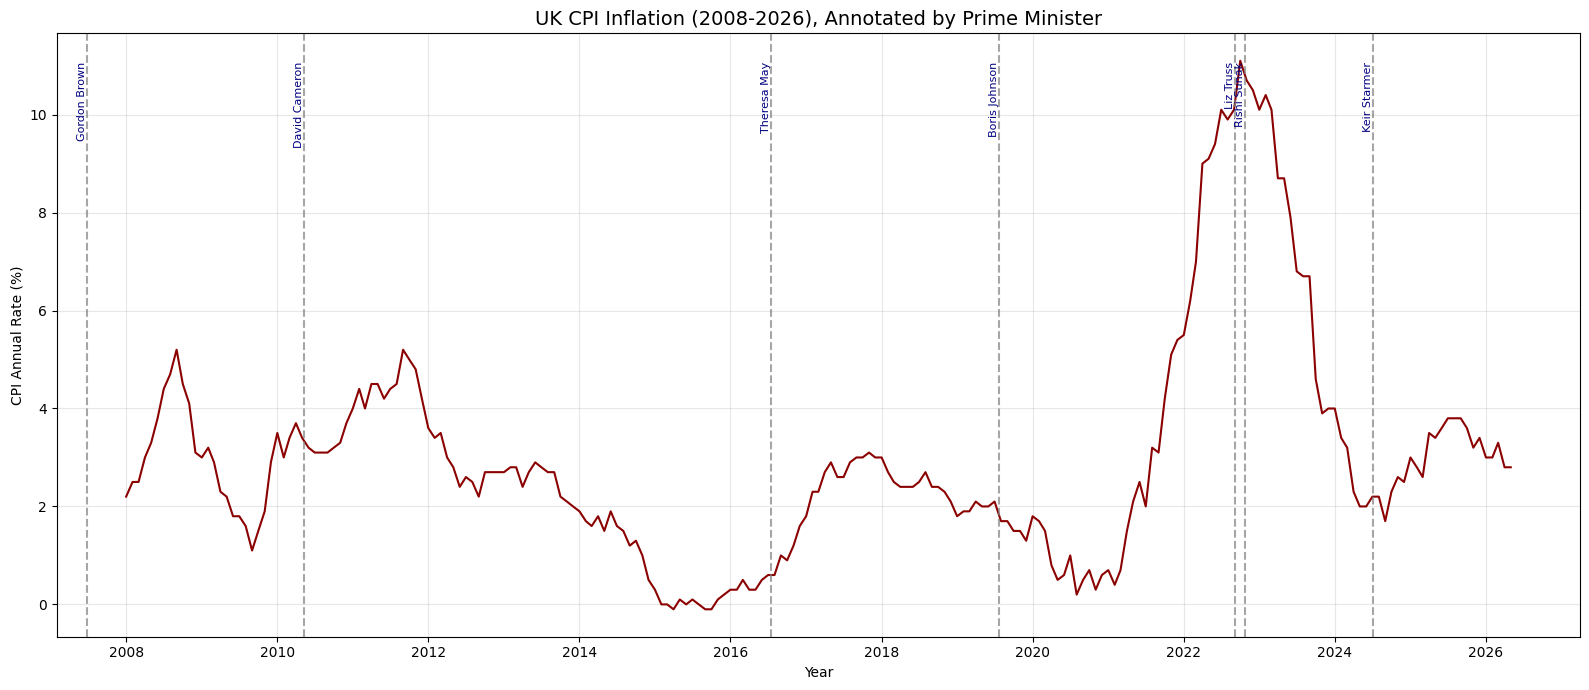

Chart saved as chart1_cpi_by_pm.png


In [37]:
import matplotlib.pyplot as plt

cpi_data = pd.read_sql("SELECT * FROM fact_cpi_monthly ORDER BY date_key", con=engine)
pm_data = pd.read_sql("SELECT * FROM dim_pm ORDER BY start_date", con=engine)

cpi_data["date"] = pd.to_datetime(cpi_data["date_key"], format="%Y%m%d")

# Exclude Tony Blair - his tenure starts in 1997, before our CPI data begins (2008)
pm_data = pm_data[pm_data["pm_name"] != "Tony Blair"]

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(cpi_data["date"], cpi_data["cpi_annual_rate_pct"], color="darkred", linewidth=1.5)

for _, pm in pm_data.iterrows():
    ax.axvline(pm["start_date"], color="gray", linestyle="--", alpha=0.7)
    ax.text(pm["start_date"], ax.get_ylim()[1]*0.95, pm["pm_name"],
            rotation=90, fontsize=8, va="top", ha="right", color="navy")

ax.set_title("UK CPI Inflation (2008-2026), Annotated by Prime Minister", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("CPI Annual Rate (%)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("chart1_cpi_by_pm.png", dpi=150)
plt.show()

print("Chart saved as chart1_cpi_by_pm.png")

## Combined Annual Data - Correlation

Combined annual data:
    year  debt_to_gdp_pct  gilt_10y_yield_pct   avg_cpi     avg_ftse  \
0   2008             47.6              4.5948  3.608333  5371.572381   
1   2009             60.6              3.6481  2.183333  4566.085236   
2   2010             70.1              3.6180  3.308333  5467.867431   
3   2011             73.8              3.1241  4.475000  5682.832960   
4   2012             77.3              1.9162  2.841667  5743.260238   
5   2013             79.2              2.3921  2.566667  6472.016917   
6   2014             81.5              2.5685  1.458333  6680.893083   
7   2015             81.7              1.9032  0.041667  6590.277510   
8   2016             82.5              1.2981  0.675000  6474.405336   
9   2017             81.7              1.2366  2.683333  7379.869008   
10  2018             81.3              1.4607  2.483333  7362.887075   
11  2019             84.2              0.9324  1.791667  7276.482767   
12  2020             97.6              0.3

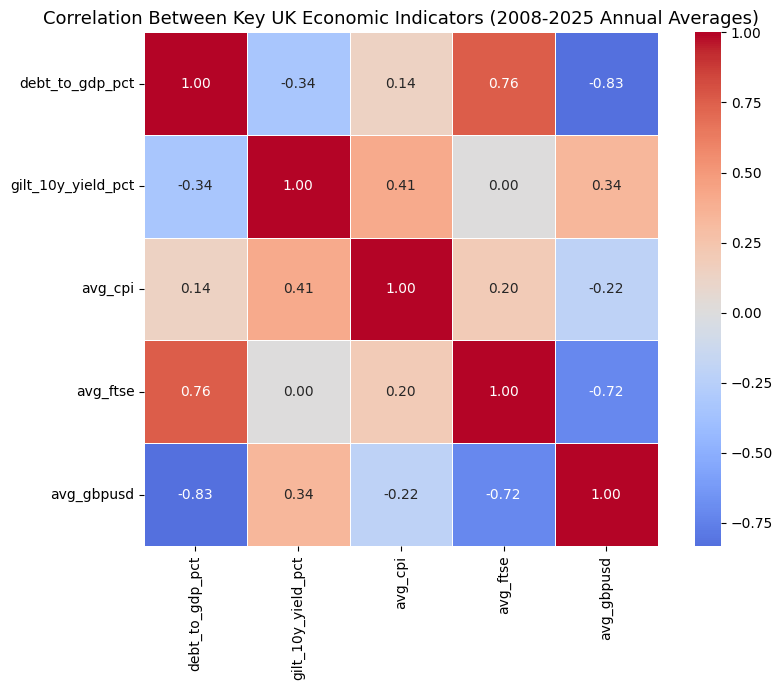


Chart saved as chart2_correlation_heatmap.png


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Step 1: Build one annual table combining everything ----
# CPI and market data are monthly/daily - we average them up to yearly
# so they can be compared fairly against the already-annual debt/gilt data.

query = """
SELECT
    a.year,
    a.debt_to_gdp_pct,
    a.gilt_10y_yield_pct,
    (SELECT AVG(cpi_annual_rate_pct) FROM fact_cpi_monthly
     WHERE FLOOR(date_key/10000) = a.year) AS avg_cpi,
    (SELECT AVG(ftse_close) FROM fact_markets_daily
     WHERE FLOOR(date_key/10000) = a.year) AS avg_ftse,
    (SELECT AVG(gbpusd_close) FROM fact_markets_daily
     WHERE FLOOR(date_key/10000) = a.year) AS avg_gbpusd
FROM fact_annual_indicators a
WHERE a.year >= 2008
ORDER BY a.year;
"""

corr_data = pd.read_sql(query, con=engine)
print("Combined annual data:")
print(corr_data)

# ---- Step 2: Calculate the correlation matrix ----
# .corr() automatically compares every column against every other column
# and gives a number from -1 (opposite direction) to +1 (move together)

correlation_matrix = corr_data.drop(columns=["year"]).corr()

print("\nCorrelation matrix:")
print(correlation_matrix)

# ---- Step 3: Plot as a heatmap ----
plt.figure(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=0.5)
plt.title("Correlation Between Key UK Economic Indicators (2008-2025 Annual Averages)", fontsize=13)
plt.tight_layout()
plt.savefig("chart2_correlation_heatmap.png", dpi=150)
plt.show()

print("\nChart saved as chart2_correlation_heatmap.png")

## Truss mini-budget & Its Impact on FTSE and GBP/USD

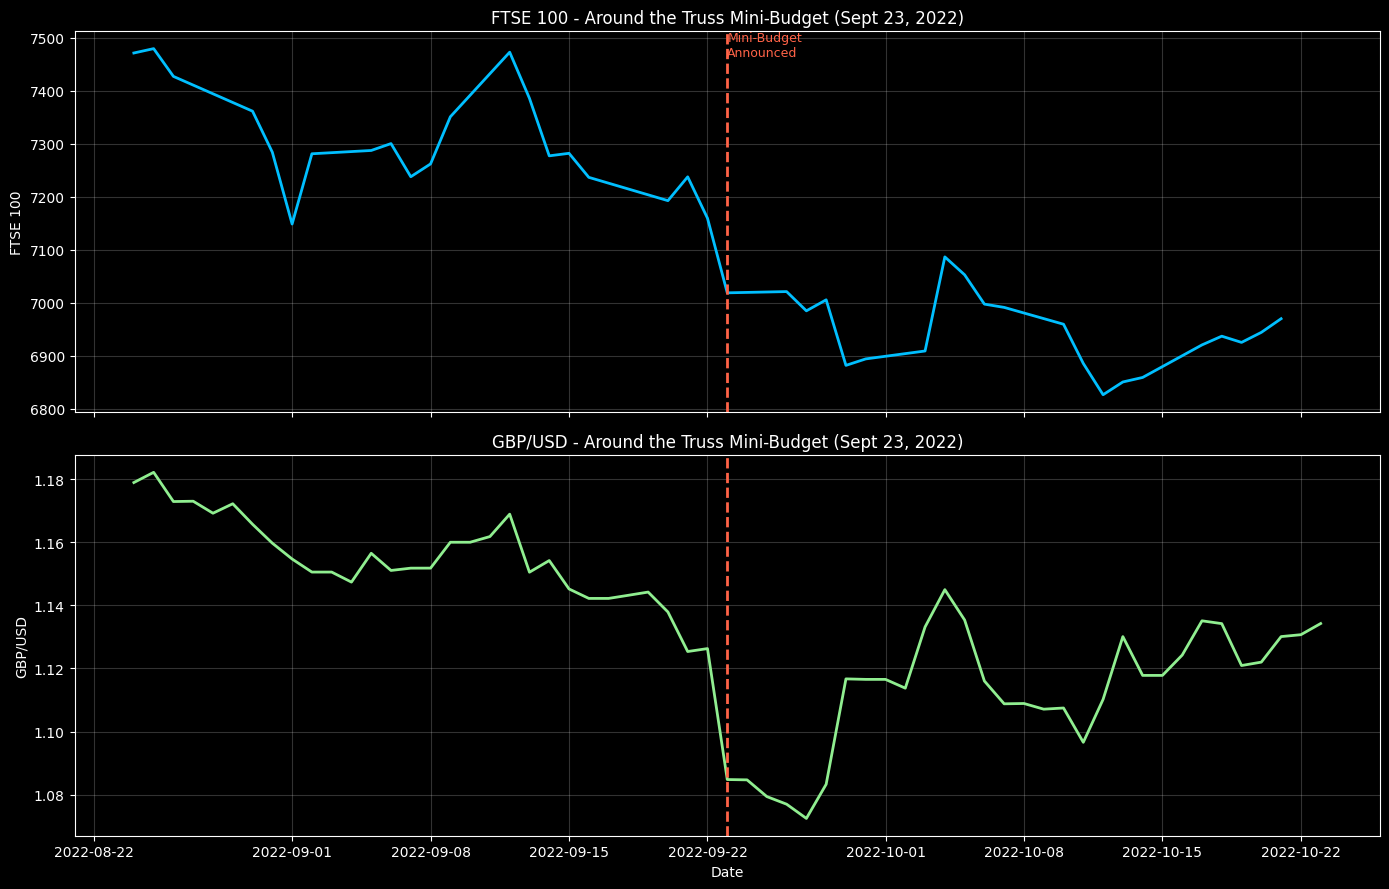

Chart saved as chart3_truss_event_zoom.png


In [39]:
import matplotlib.pyplot as plt

# ADD THIS ONE LINE at the top, before creating any chart - it changes
# the background, text, and gridline colors to a dark theme automatically
plt.style.use("dark_background")

query = """
SELECT date_key, ftse_close, gbpusd_close
FROM fact_markets_daily
WHERE date_key BETWEEN 20220824 AND 20221023
ORDER BY date_key;
"""

truss_data = pd.read_sql(query, con=engine)
truss_data["date"] = pd.to_datetime(truss_data["date_key"], format="%Y%m%d")

mini_budget_date = pd.Timestamp("2022-09-23")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ftse_clean = truss_data.dropna(subset=["ftse_close"])
ax1.plot(ftse_clean["date"], ftse_clean["ftse_close"], color="deepskyblue", linewidth=2)
ax1.axvline(mini_budget_date, color="tomato", linestyle="--", linewidth=2)
ax1.text(mini_budget_date, ax1.get_ylim()[1], "Mini-Budget\nAnnounced", color="tomato",
         fontsize=9, ha="left", va="top")
ax1.set_title("FTSE 100 - Around the Truss Mini-Budget (Sept 23, 2022)")
ax1.set_ylabel("FTSE 100")
ax1.grid(alpha=0.2)

gbp_clean = truss_data.dropna(subset=["gbpusd_close"])
ax2.plot(gbp_clean["date"], gbp_clean["gbpusd_close"], color="lightgreen", linewidth=2)
ax2.axvline(mini_budget_date, color="tomato", linestyle="--", linewidth=2)
ax2.set_title("GBP/USD - Around the Truss Mini-Budget (Sept 23, 2022)")
ax2.set_ylabel("GBP/USD")
ax2.set_xlabel("Date")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("chart3_truss_event_zoom.png", dpi=150)
plt.show()

print("Chart saved as chart3_truss_event_zoom.png")

## FTSE 100 vs S&P 500, indexed to 100 at the start of 2008

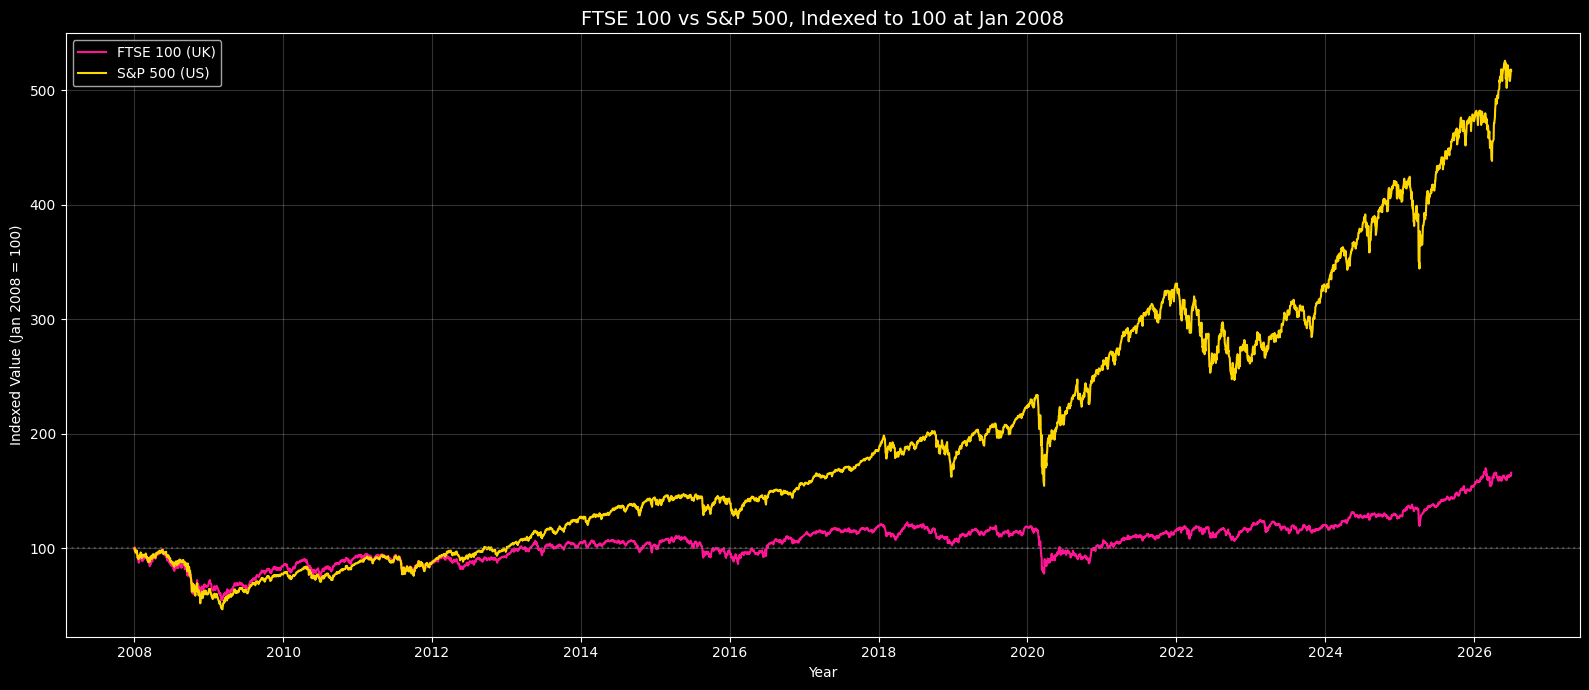

Chart saved as chart4_ftse_vs_sp500_indexed.png

Final FTSE indexed value: 166.0
Final S&P 500 indexed value: 517.1


In [40]:
import matplotlib.pyplot as plt

query = """
SELECT date_key, ftse_close, sp500_close
FROM fact_markets_daily
ORDER BY date_key;
"""

markets = pd.read_sql(query, con=engine)
markets["date"] = pd.to_datetime(markets["date_key"], format="%Y%m%d")

# Drop any rows with missing values for either index (needed for indexing)
markets = markets.dropna(subset=["ftse_close", "sp500_close"])

# ---- Indexing: convert both to "started at 100" so we can compare shape,
# not raw point values (FTSE and S&P are on totally different scales) ----
first_ftse = markets["ftse_close"].iloc[0]
first_sp500 = markets["sp500_close"].iloc[0]

markets["ftse_indexed"] = markets["ftse_close"] / first_ftse * 100
markets["sp500_indexed"] = markets["sp500_close"] / first_sp500 * 100

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(markets["date"], markets["ftse_indexed"], label="FTSE 100 (UK)", color="deeppink", linewidth=1.5)
ax.plot(markets["date"], markets["sp500_indexed"], label="S&P 500 (US)", color="gold", linewidth=1.5)

ax.axhline(100, color="gray", linestyle=":", alpha=0.5)
ax.set_title("FTSE 100 vs S&P 500, Indexed to 100 at Jan 2008", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Indexed Value (Jan 2008 = 100)")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("chart4_ftse_vs_sp500_indexed.png", dpi=150)
plt.show()

print("Chart saved as chart4_ftse_vs_sp500_indexed.png")

# Print the final indexed values so we have the headline number for the writeup
print(f"\nFinal FTSE indexed value: {markets['ftse_indexed'].iloc[-1]:.1f}")
print(f"Final S&P 500 indexed value: {markets['sp500_indexed'].iloc[-1]:.1f}")

## Non-Dom count trend vs. Tax-to-GDP

    tax_year  non_dom_only_count  tax_to_gdp_pct
0    2015/16            119400.0           37.61
1    2019/20             79500.0           38.13
2    2020/21             68300.0           38.85
4  2023 (YE)             74000.0           40.48
5  2024 (YE)             73700.0           40.22


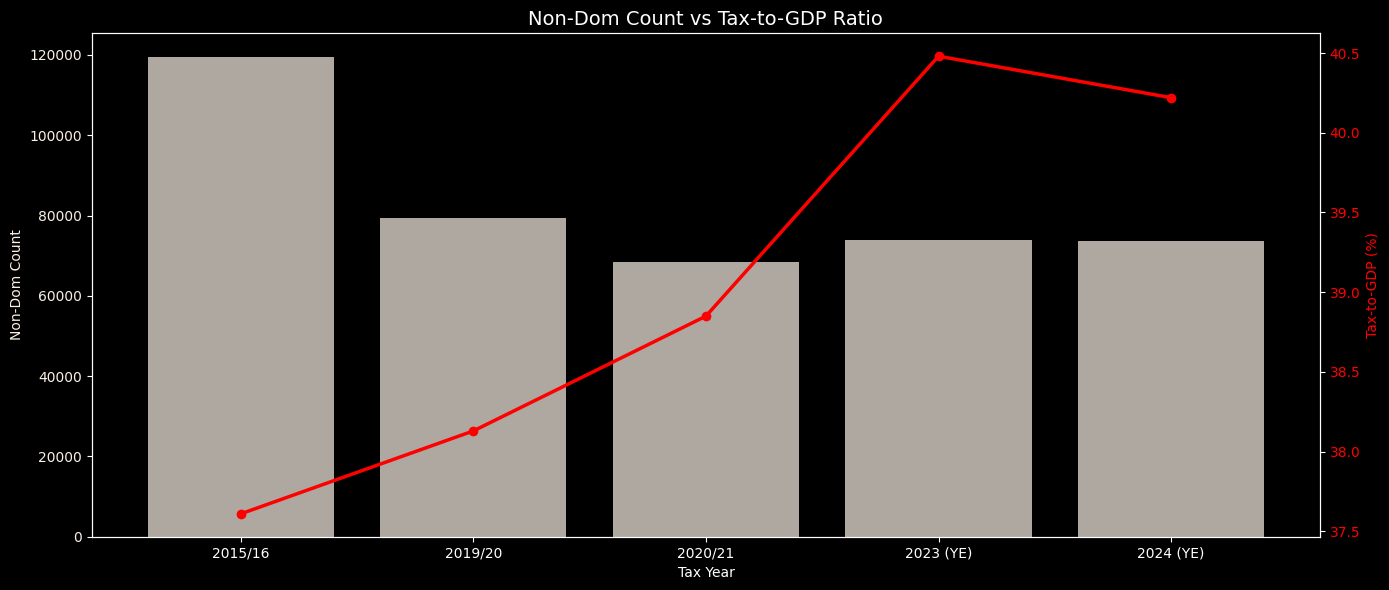

Chart saved as chart5_nondom_vs_tax.png


In [41]:
import matplotlib.pyplot as plt

query = """
SELECT
    n.tax_year,
    n.non_dom_only_count,
    a.tax_to_gdp_pct
FROM fact_wealth_nondom n
LEFT JOIN fact_annual_indicators a
    ON a.year = CAST(SUBSTRING(n.tax_year, 1, 4) AS UNSIGNED)
ORDER BY n.tax_year;
"""

wealth_data = pd.read_sql(query, con=engine)
wealth_data = wealth_data.dropna(subset=["non_dom_only_count"])  # drop the one row with no non-dom figure

print(wealth_data)

# ---- Dual-axis chart: two different y-axes sharing the same x-axis ----
fig, ax1 = plt.subplots(figsize=(14, 6))

# Left axis: non-dom count (bars)
ax1.bar(wealth_data["tax_year"], wealth_data["non_dom_only_count"], color="linen", alpha=0.7, label="Non-Dom Count")
ax1.set_xlabel("Tax Year")
ax1.set_ylabel("Non-Dom Count", color="linen")
ax1.tick_params(axis="y", labelcolor="linen")

# Right axis: tax-to-GDP (line) - ax2 shares the same x-axis as ax1
ax2 = ax1.twinx()
ax2.plot(wealth_data["tax_year"], wealth_data["tax_to_gdp_pct"], color="red", linewidth=2.5, marker="o", label="Tax-to-GDP %")
ax2.set_ylabel("Tax-to-GDP (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Non-Dom Count vs Tax-to-GDP Ratio", fontsize=14)
fig.tight_layout()
plt.savefig("chart5_nondom_vs_tax.png", dpi=150)
plt.show()

print("Chart saved as chart5_nondom_vs_tax.png")

# Scenario Modeling

## Debt trajectory projection to 2030

Historical data:
    year  debt_to_gdp_pct
0   2008             47.6
1   2009             60.6
2   2010             70.1
3   2011             73.8
4   2012             77.3
5   2013             79.2
6   2014             81.5
7   2015             81.7
8   2016             82.5
9   2017             81.7
10  2018             81.3
11  2019             84.2
12  2020             97.6
13  2021             96.2
14  2022             93.1
15  2023             95.6
16  2024             94.7
17  2025             94.7

Trend equation: debt_to_gdp = 2.236 * year + -4426.4
This means debt-to-GDP has been rising by about 2.24 percentage points per year, on average.

Projected values (simple trend extrapolation, NOT a prediction model):
   year  projected_debt_to_gdp_pct
0  2026                 103.094771
1  2027                 105.330478
2  2028                 107.566185
3  2029                 109.801892
4  2030                 112.037599


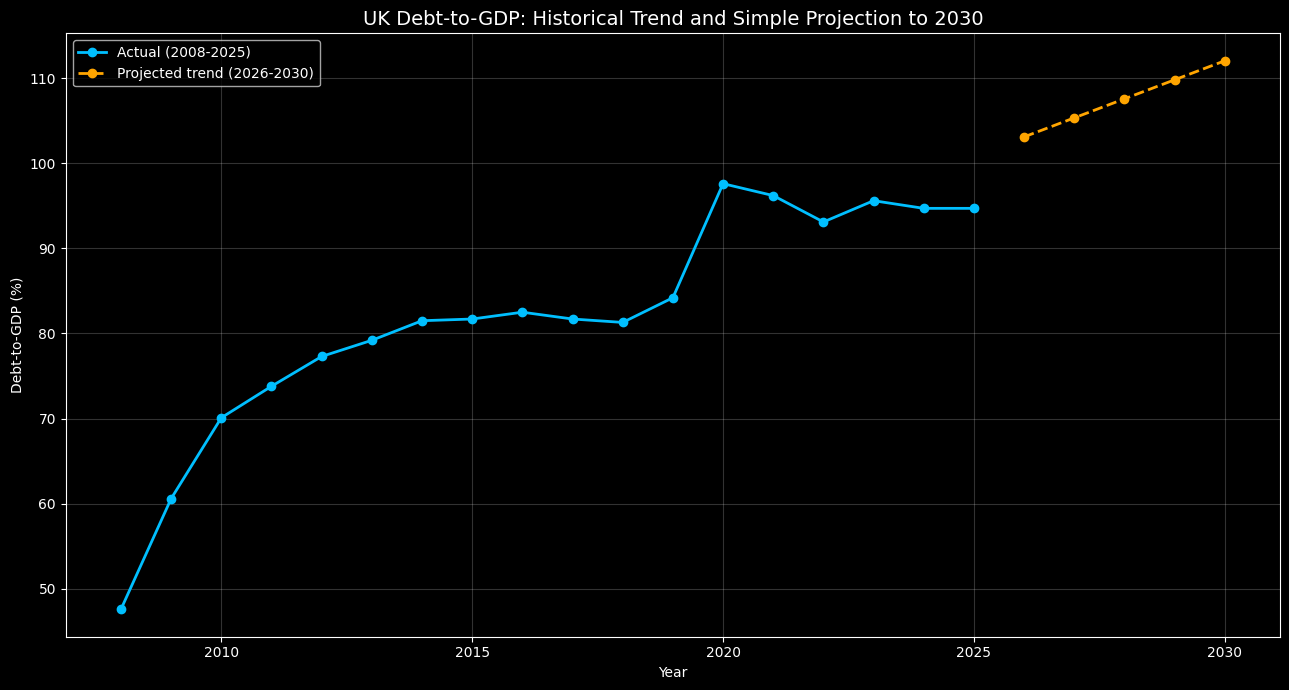


Chart saved as scenario1_debt_projection.png


In [42]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Step 1: Pull the historical debt-to-GDP data ----
debt_data = pd.read_sql("""
    SELECT year, debt_to_gdp_pct
    FROM fact_annual_indicators
    WHERE debt_to_gdp_pct IS NOT NULL
    ORDER BY year
""", con=engine)

print("Historical data:")
print(debt_data)

# ---- Step 2: Fit a simple straight-line trend (this is NOT machine learning -
# it's the same "line of best fit" math you'd do in Excel with a trendline) ----
# np.polyfit with degree=1 finds the slope and intercept of the best-fit line
# through our historical points.

x = debt_data["year"].values
y = debt_data["debt_to_gdp_pct"].values

slope, intercept = np.polyfit(x, y, deg=1)

print(f"\nTrend equation: debt_to_gdp = {slope:.3f} * year + {intercept:.1f}")
print(f"This means debt-to-GDP has been rising by about {slope:.2f} percentage points per year, on average.")

# ---- Step 3: Extend the line forward to 2030 ----
future_years = np.arange(2026, 2031)
projected_values = slope * future_years + intercept

projection_df = pd.DataFrame({"year": future_years, "projected_debt_to_gdp_pct": projected_values})
print("\nProjected values (simple trend extrapolation, NOT a prediction model):")
print(projection_df)

# ---- Step 4: Plot historical + projected together ----
fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(debt_data["year"], debt_data["debt_to_gdp_pct"], marker="o", color="deepskyblue",
        linewidth=2, label="Actual (2008-2025)")
ax.plot(projection_df["year"], projection_df["projected_debt_to_gdp_pct"], marker="o",
        linestyle="--", color="orange", linewidth=2, label="Projected trend (2026-2030)")

ax.set_title("UK Debt-to-GDP: Historical Trend and Simple Projection to 2030", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Debt-to-GDP (%)")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("scenario1_debt_projection.png", dpi=150)
plt.show()

print("\nChart saved as scenario1_debt_projection.png")

## Bond yield sensitivity

Most recent year's data:
   year  debt_to_gdp_pct  gdp_current_price_gbpm  gilt_10y_yield_pct
0  2025             94.7                 3039861              4.5833

In 2025:
  Total UK national debt: approximately £2,878.7 billion
  Current 10-year gilt yield: 4.58%

SCENARIO: If gilt yields rose by 1.0 percentage point (as happened under Truss):
  Extra annual interest cost: approximately £28.8 billion per year
  (This assumes the spike applies across all existing debt - a simplified upper-bound estimate)


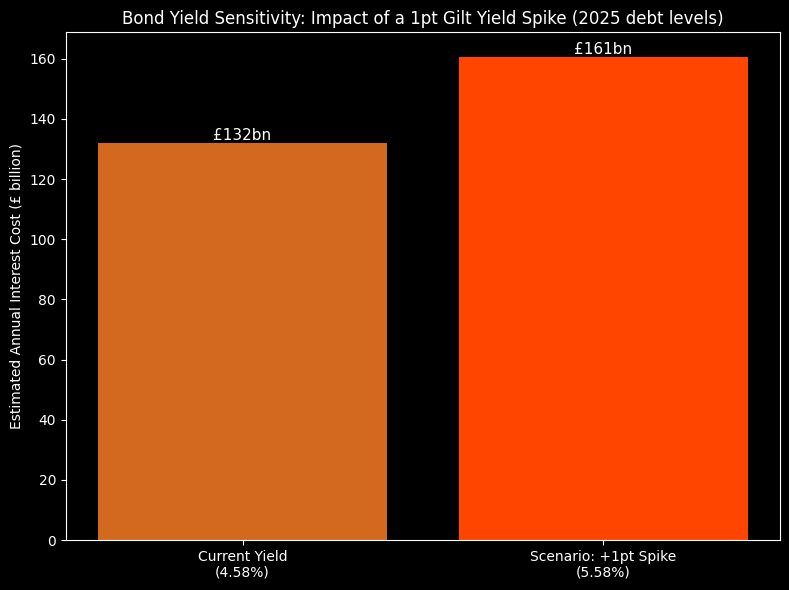


Chart saved as scenario2_gilt_yield_sensitivity.png


In [43]:
import matplotlib.pyplot as plt

# ---- Step 1: Get the most recent year's debt and GDP figures ----
latest = pd.read_sql("""
    SELECT year, debt_to_gdp_pct, gdp_current_price_gbpm, gilt_10y_yield_pct
    FROM fact_annual_indicators
    WHERE debt_to_gdp_pct IS NOT NULL AND gdp_current_price_gbpm IS NOT NULL
    ORDER BY year DESC
    LIMIT 1
""", con=engine)

print("Most recent year's data:")
print(latest)

latest_year = latest["year"].iloc[0]
debt_to_gdp_pct = latest["debt_to_gdp_pct"].iloc[0]
gdp_gbpm = latest["gdp_current_price_gbpm"].iloc[0]
current_gilt_yield = latest["gilt_10y_yield_pct"].iloc[0]

# ---- Step 2: Calculate actual total debt in GBP ----
# debt_to_gdp_pct is a percentage, so we convert it back to an actual pound amount
total_debt_gbpm = (debt_to_gdp_pct / 100) * gdp_gbpm

print(f"\nIn {latest_year}:")
print(f"  Total UK national debt: approximately £{total_debt_gbpm/1000:,.1f} billion")
print(f"  Current 10-year gilt yield: {current_gilt_yield:.2f}%")

# ---- Step 3: The "what-if" - a 1 percentage point yield spike ----
# SIMPLIFYING ASSUMPTION (stated clearly): this assumes the spike applies to
# ALL government debt uniformly. In reality only debt that matures/refinances
# during the spike period is affected - but this gives us a clean, honest
# upper-bound estimate of the scale involved, which is standard practice for
# a simple sensitivity analysis like this.

yield_spike_pct = 1.0  # 1 percentage point, matching the real Truss-era move

extra_annual_interest_gbpm = total_debt_gbpm * (yield_spike_pct / 100)

print(f"\nSCENARIO: If gilt yields rose by {yield_spike_pct} percentage point (as happened under Truss):")
print(f"  Extra annual interest cost: approximately £{extra_annual_interest_gbpm/1000:,.1f} billion per year")
print(f"  (This assumes the spike applies across all existing debt - a simplified upper-bound estimate)")

# ---- Step 4: Simple bar chart comparing current vs scenario interest burden ----
current_annual_interest_gbpm = total_debt_gbpm * (current_gilt_yield / 100)
scenario_annual_interest_gbpm = total_debt_gbpm * ((current_gilt_yield + yield_spike_pct) / 100)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    ["Current Yield\n({:.2f}%)".format(current_gilt_yield), "Scenario: +1pt Spike\n({:.2f}%)".format(current_gilt_yield + yield_spike_pct)],
    [current_annual_interest_gbpm/1000, scenario_annual_interest_gbpm/1000],
    color=["chocolate", "orangered"]
)
ax.set_ylabel("Estimated Annual Interest Cost (£ billion)")
ax.set_title(f"Bond Yield Sensitivity: Impact of a 1pt Gilt Yield Spike ({latest_year} debt levels)", fontsize=12)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"£{height:,.0f}bn", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("scenario2_gilt_yield_sensitivity.png", dpi=150)
plt.show()

print("\nChart saved as scenario2_gilt_yield_sensitivity.png")

## what would an equally-sized oil price shock look like if it happened again today?

Energy price cap history:
    date_key period_label  annual_bill_gbp
0   20190101      2019 Q1             1137
1   20210401      2021 Q2             1138
2   20211001      2021 Q4             1277
3   20220401      2022 Q2             1971
4   20221001      2022 Q4             2500
5   20230101      2023 Q1             2500
6   20230401      2023 Q2             2074
7   20230701      2023 Q3             1923
8   20231001      2023 Q4             1834
9   20240101      2024 Q1             1928
10  20240401      2024 Q2             1690
11  20240701      2024 Q3             1568
12  20241001      2024 Q4             1717
13  20250401      2025 Q2             1849
14  20250701      2025 Q3             1720
15  20251001      2025 Q4             1755
16  20260101      2026 Q1             1758
17  20260401      2026 Q2             1641
18  20260701      2026 Q3             1862

2022 energy shock: bill rose from £1971 to £2500
That's a 26.8% increase in one shock event.

Current baseline (2

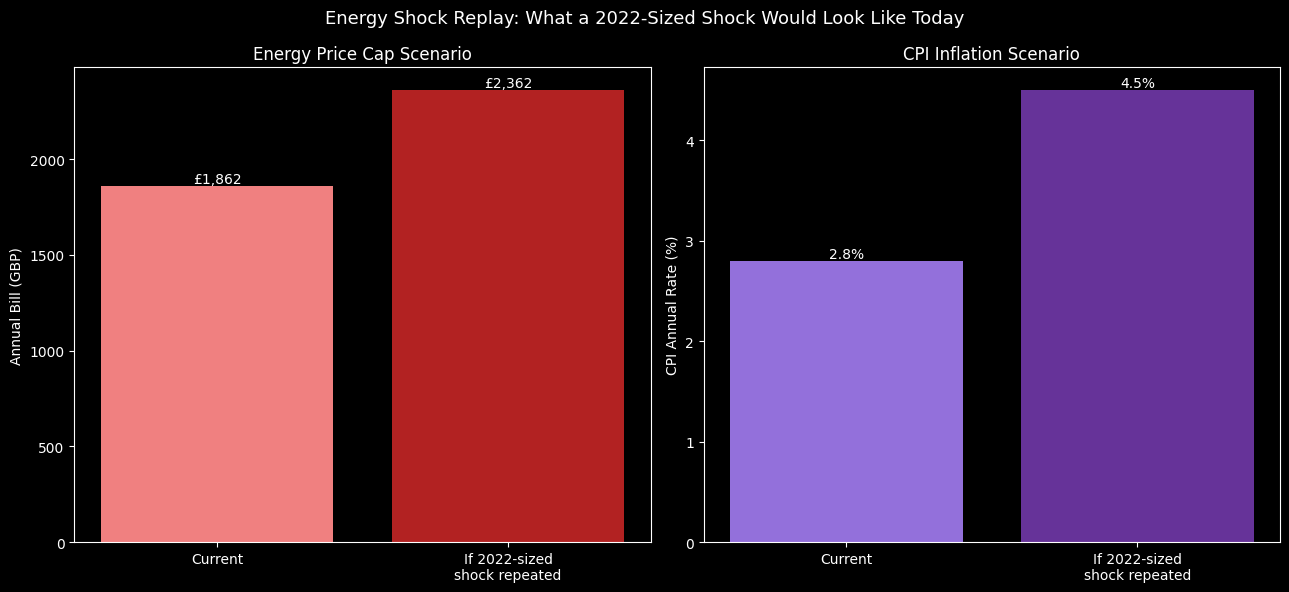


Chart saved as scenario3_energy_shock_replay.png


In [44]:
import matplotlib.pyplot as plt

# ---- Step 1: Measure the actual size of the 2022 energy shock ----
energy_data = pd.read_sql("SELECT * FROM fact_energy_price_cap ORDER BY date_key", con=engine)
print("Energy price cap history:")
print(energy_data)

# Pre-shock baseline (before the crisis) vs peak (during the crisis)
pre_shock = energy_data[energy_data["period_label"] == "2022 Q2"]["annual_bill_gbp"].iloc[0]
peak_shock = energy_data[energy_data["period_label"] == "2022 Q4"]["annual_bill_gbp"].iloc[0]

shock_pct_increase = (peak_shock - pre_shock) / pre_shock * 100

print(f"\n2022 energy shock: bill rose from £{pre_shock} to £{peak_shock}")
print(f"That's a {shock_pct_increase:.1f}% increase in one shock event.")

# ---- Step 2: Apply that same % increase to TODAY's baseline ----
latest_bill = energy_data["annual_bill_gbp"].iloc[-1]
latest_period = energy_data["period_label"].iloc[-1]

hypothetical_bill = latest_bill * (1 + shock_pct_increase / 100)

print(f"\nCurrent baseline ({latest_period}): £{latest_bill}")
print(f"IF a shock of the same size happened again: bill would jump to approximately £{hypothetical_bill:,.0f}")


# ---- Step 3: Do the same exercise for CPI ----
cpi_data = pd.read_sql("SELECT * FROM fact_cpi_monthly ORDER BY date_key", con=engine)

cpi_pre_shock = cpi_data[cpi_data["date_key"] == 20220601]["cpi_annual_rate_pct"].iloc[0]
cpi_peak_shock = cpi_data[cpi_data["date_key"] == 20221001]["cpi_annual_rate_pct"].iloc[0]

cpi_point_increase = cpi_peak_shock - cpi_pre_shock

print(f"\n2022 CPI shock: inflation rose from {cpi_pre_shock}% to {cpi_peak_shock}% ({cpi_point_increase:+.1f} percentage points)")

latest_cpi = cpi_data["cpi_annual_rate_pct"].iloc[-1]
latest_cpi_period = cpi_data["date_key"].iloc[-1]
hypothetical_cpi = latest_cpi + cpi_point_increase

print(f"Current baseline CPI: {latest_cpi}%")
print(f"IF a shock of the same size happened again: CPI would jump to approximately {hypothetical_cpi:.1f}%")

# ---- Step 4: Chart comparing baseline vs hypothetical scenario ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

ax1.bar(["Current", "If 2022-sized\nshock repeated"], [latest_bill, hypothetical_bill], color=["lightcoral", "firebrick"])
ax1.set_title("Energy Price Cap Scenario")
ax1.set_ylabel("Annual Bill (GBP)")
for i, v in enumerate([latest_bill, hypothetical_bill]):
    ax1.text(i, v, f"£{v:,.0f}", ha="center", va="bottom")

ax2.bar(["Current", "If 2022-sized\nshock repeated"], [latest_cpi, hypothetical_cpi], color=["mediumpurple", "rebeccapurple"])
ax2.set_title("CPI Inflation Scenario")
ax2.set_ylabel("CPI Annual Rate (%)")
for i, v in enumerate([latest_cpi, hypothetical_cpi]):
    ax2.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.suptitle("Energy Shock Replay: What a 2022-Sized Shock Would Look Like Today", fontsize=13)
plt.tight_layout()
plt.savefig("scenario3_energy_shock_replay.png", dpi=150)
plt.show()

print("\nChart saved as scenario3_energy_shock_replay.png")

## Misery Index under continued Iran War disruption

Real event from our data:
  event_date            event_name    event_type  \
0 2026-02-15  Outbreak of Iran War  Global Shock   

                                         description  
0  Geopolitical escalation triggers a sudden surg...  

CPI just before Iran War outbreak (Jan 2026): 3.0%
CPI most recently available (20260501): 2.8%
Average monthly change since the war began: -0.05 points/month

SCENARIO: If this pace of change continued for 6 more months,
projected CPI would be approximately 2.5%

Current Misery Index (latest CPI + 2025 unemployment): 7.6
Projected Misery Index if disruption continues: 7.3


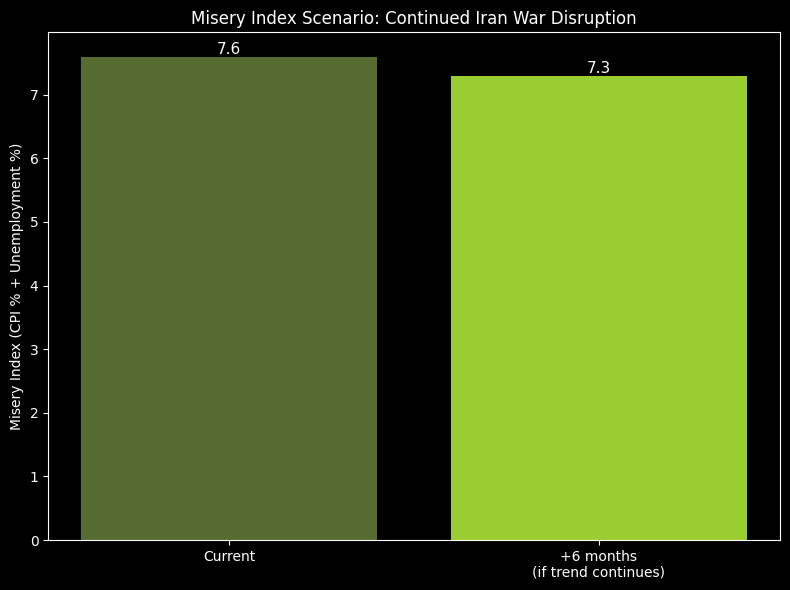


Chart saved as scenario4_misery_index_iran_war.png


In [45]:
import matplotlib.pyplot as plt

# ---- Step 1: Confirm the real event from our data ----
event = pd.read_sql("""
    SELECT * FROM dim_event WHERE event_name = 'Outbreak of Iran War'
""", con=engine)
print("Real event from our data:")
print(event)

# ---- Step 2: Measure CPI movement since the war started ----
cpi_data = pd.read_sql("SELECT * FROM fact_cpi_monthly ORDER BY date_key", con=engine)

# CPI right before the war (Jan 2026) vs the most recent reading we have (May 2026)
cpi_before_war = cpi_data[cpi_data["date_key"] == 20260101]["cpi_annual_rate_pct"].iloc[0]
cpi_latest = cpi_data["cpi_annual_rate_pct"].iloc[-1]
latest_date_key = cpi_data["date_key"].iloc[-1]

months_elapsed = 4  # Jan 2026 to May 2026
monthly_change_rate = (cpi_latest - cpi_before_war) / months_elapsed

print(f"\nCPI just before Iran War outbreak (Jan 2026): {cpi_before_war}%")
print(f"CPI most recently available ({latest_date_key}): {cpi_latest}%")
print(f"Average monthly change since the war began: {monthly_change_rate:+.2f} points/month")

# ---- Step 3: Project forward IF this same monthly pace continued for 6 more months ----
# SIMPLIFYING ASSUMPTION: this assumes disruption continues at the SAME pace observed
# so far - a straightforward "if this trend continues" projection, not a prediction model.

months_forward = 6
projected_cpi = cpi_latest + (monthly_change_rate * months_forward)

print(f"\nSCENARIO: If this pace of change continued for {months_forward} more months,")
print(f"projected CPI would be approximately {projected_cpi:.1f}%")

# ---- Step 4: Combine with latest unemployment for a Misery Index comparison ----
# Unemployment is only available annually, so we use the latest known year as a
# flat baseline (stated assumption: unemployment doesn't change in this scenario,
# since we have no monthly unemployment data to trend from)

unemployment = pd.read_sql("""
    SELECT year, unemployment_rate_pct FROM fact_annual_indicators
    WHERE unemployment_rate_pct IS NOT NULL ORDER BY year DESC LIMIT 1
""", con=engine)
latest_unemployment = unemployment["unemployment_rate_pct"].iloc[0]
latest_unemployment_year = unemployment["year"].iloc[0]

current_misery_index = cpi_latest + latest_unemployment
projected_misery_index = projected_cpi + latest_unemployment

print(f"\nCurrent Misery Index (latest CPI + {latest_unemployment_year} unemployment): {current_misery_index:.1f}")
print(f"Projected Misery Index if disruption continues: {projected_misery_index:.1f}")

# ---- Step 5: Chart ----
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(["Current", f"+{months_forward} months\n(if trend continues)"],
              [current_misery_index, projected_misery_index],
              color=["darkolivegreen", "yellowgreen"])
ax.set_title("Misery Index Scenario: Continued Iran War Disruption", fontsize=12)
ax.set_ylabel("Misery Index (CPI % + Unemployment %)")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.1f}", ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("scenario4_misery_index_iran_war.png", dpi=150)
plt.show()

print("\nChart saved as scenario4_misery_index_iran_war.png")

In [46]:
count = pd.read_sql("SELECT COUNT(*) as total FROM dim_date", con=engine)
print(count)

   total
0   6940
